# Section 04 — Exploratory Data Analysis
## 4.1 Price Distributions
**Assignment:** Visualize price distributions by city, neighbourhood, room type, and property type.

**Dataset:** Amsterdam Airbnb — master_listings.parquet (10,480 listings, 5,874 with valid price)

**Business context:** Price distribution analysis helps hosts benchmark their pricing, helps investors identify high-value neighbourhoods, and helps platform operators understand market structure.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Style ─────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        150,
    'font.family':       'sans-serif',
    'font.size':         11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
})

BLUE   = '#185FA5'
TEAL   = '#1D9E75'
AMBER  = '#BA7517'
RED    = '#A32D2D'
PURPLE = '#534AB7'
COLORS = [BLUE, TEAL, AMBER, RED, PURPLE,
          '#639922', '#D4537E', '#888780', '#EF9F27']

REPORT_DIR = Path('../reports')
REPORT_DIR.mkdir(exist_ok=True)

# ── Load master table ─────────────────────────────────────────
master = pd.read_parquet('../data/processed/master_listings.parquet')

# Filter to valid-price listings for ALL price analyses
valid = master[master['_is_valid'] == True].copy()

print(f'Total listings       : {len(master):,}')
print(f'Valid price listings : {len(valid):,}')
print(f'Price range          : €{valid["price"].min():.0f} – €{valid["price"].max():,.0f}')
print(f'Median price         : €{valid["price"].median():.0f}')
print(f'Mean price           : €{valid["price"].mean():.0f}  (note: mean > median due to luxury outliers)')

Total listings       : 10,480
Valid price listings : 5,874
Price range          : €35 – €80,018
Median price         : €222
Mean price           : €337  (note: mean > median due to luxury outliers)


---
## Chart 1 — Overall Amsterdam Price Distribution
Understanding the shape of the market before segmenting by any dimension.

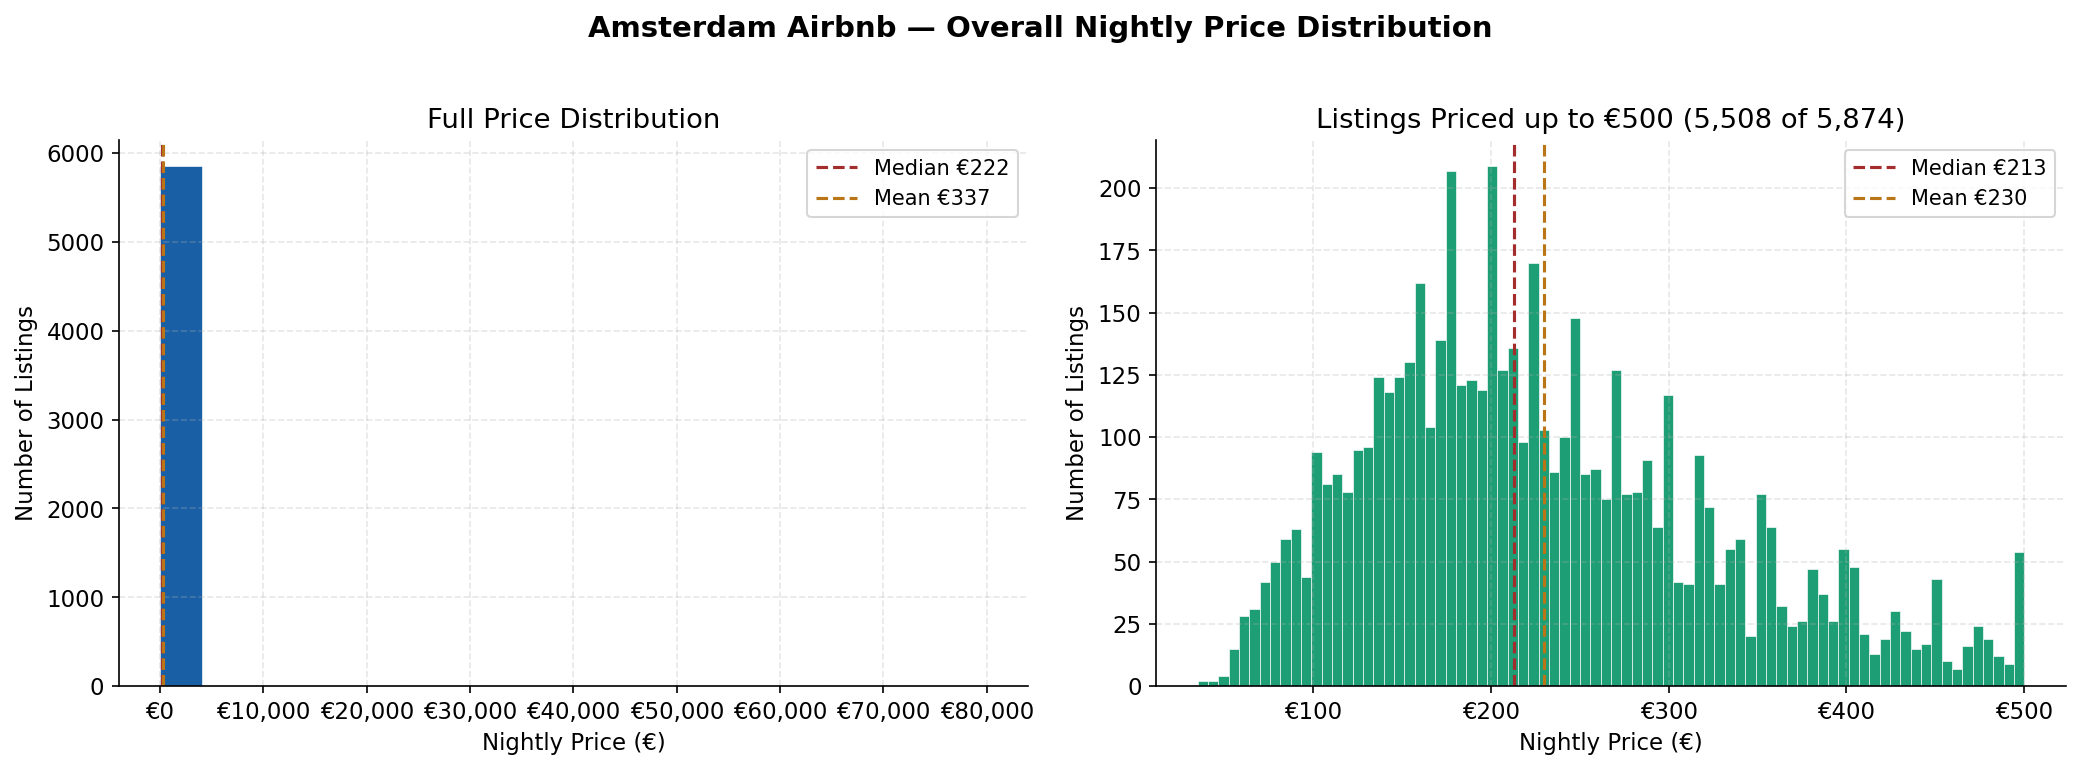


Price Percentiles
------------------------------
P10: €    116
P25: €    161
P50: €    222
P75: €    314
P90: €    437
P95: €    550
P99: €    992

93.8% of listings are priced at €500 or below.

📋 Business Interpretation

The price distribution is right-skewed, meaning that most Airbnb listings
have moderate prices, while a small number of luxury properties have
very high prices.

The median price is €222 per night, while the
mean price is €337. Since the mean is higher than
the median, it shows that expensive listings increase the average price.

About 90% of listings cost less than €437
per night, indicating that luxury listings make up only a small part of
the Amsterdam Airbnb market.

For hosts, the median price is a better guide than the mean because it
represents the typical listing price. Hosts should also compare their
prices with similar room types and neighbourhoods instead of using the
overall market average.



In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Amsterdam Airbnb — Overall Nightly Price Distribution',
    fontsize=14,
    fontweight='bold',
    y=1.02
)

# ── Left: Full price distribution ───────────────────────────
ax = axes[0]

ax.hist(
    valid['price'],
    bins=20,
    color=BLUE,
    edgecolor='white',
    linewidth=0.3
)

ax.axvline(
    valid['price'].median(),
    color=RED,
    linestyle='--',
    linewidth=1.5,
    label=f'Median €{valid["price"].median():.0f}'
)

ax.axvline(
    valid['price'].mean(),
    color=AMBER,
    linestyle='--',
    linewidth=1.5,
    label=f'Mean €{valid["price"].mean():.0f}'
)

ax.set_xlabel('Nightly Price (€)')
ax.set_ylabel('Number of Listings')
ax.set_title('Full Price Distribution')
ax.legend(fontsize=10)

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}')
)


# ── Right: Prices up to €500 only ───────────────────────────
ax2 = axes[1]

capped = valid[valid['price'] <= 500]['price']

ax2.hist(
    capped,
    bins=80,
    color=TEAL,
    edgecolor='white',
    linewidth=0.3
)

ax2.axvline(
    capped.median(),
    color=RED,
    linestyle='--',
    linewidth=1.5,
    label=f'Median €{capped.median():.0f}'
)

ax2.axvline(
    capped.mean(),
    color=AMBER,
    linestyle='--',
    linewidth=1.5,
    label=f'Mean €{capped.mean():.0f}'
)

ax2.set_xlabel('Nightly Price (€)')
ax2.set_ylabel('Number of Listings')
ax2.set_title(f'Listings Priced up to €500 ({len(capped):,} of {len(valid):,})')
ax2.legend(fontsize=10)

ax2.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}')
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR / 'fig_01_overall_price_distribution.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()


# ── Price percentiles ───────────────────────────────────────
pcts = valid['price'].quantile([0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

print("\nPrice Percentiles")
print("-" * 30)

for p, value in pcts.items():
    print(f"P{int(p*100):2d}: €{value:>7.0f}")

print(f"\n{(valid['price'] <= 500).sum() / len(valid) * 100:.1f}% of listings are priced at €500 or below.")


print(f"""
📋 Business Interpretation

The price distribution is right-skewed, meaning that most Airbnb listings
have moderate prices, while a small number of luxury properties have
very high prices.

The median price is €{valid['price'].median():.0f} per night, while the
mean price is €{valid['price'].mean():.0f}. Since the mean is higher than
the median, it shows that expensive listings increase the average price.

About 90% of listings cost less than €{valid['price'].quantile(0.90):.0f}
per night, indicating that luxury listings make up only a small part of
the Amsterdam Airbnb market.

For hosts, the median price is a better guide than the mean because it
represents the typical listing price. Hosts should also compare their
prices with similar room types and neighbourhoods instead of using the
overall market average.
""")

---
## Chart 2 — Price Distribution by Room Type
The most fundamental price segmentation in the Airbnb market.

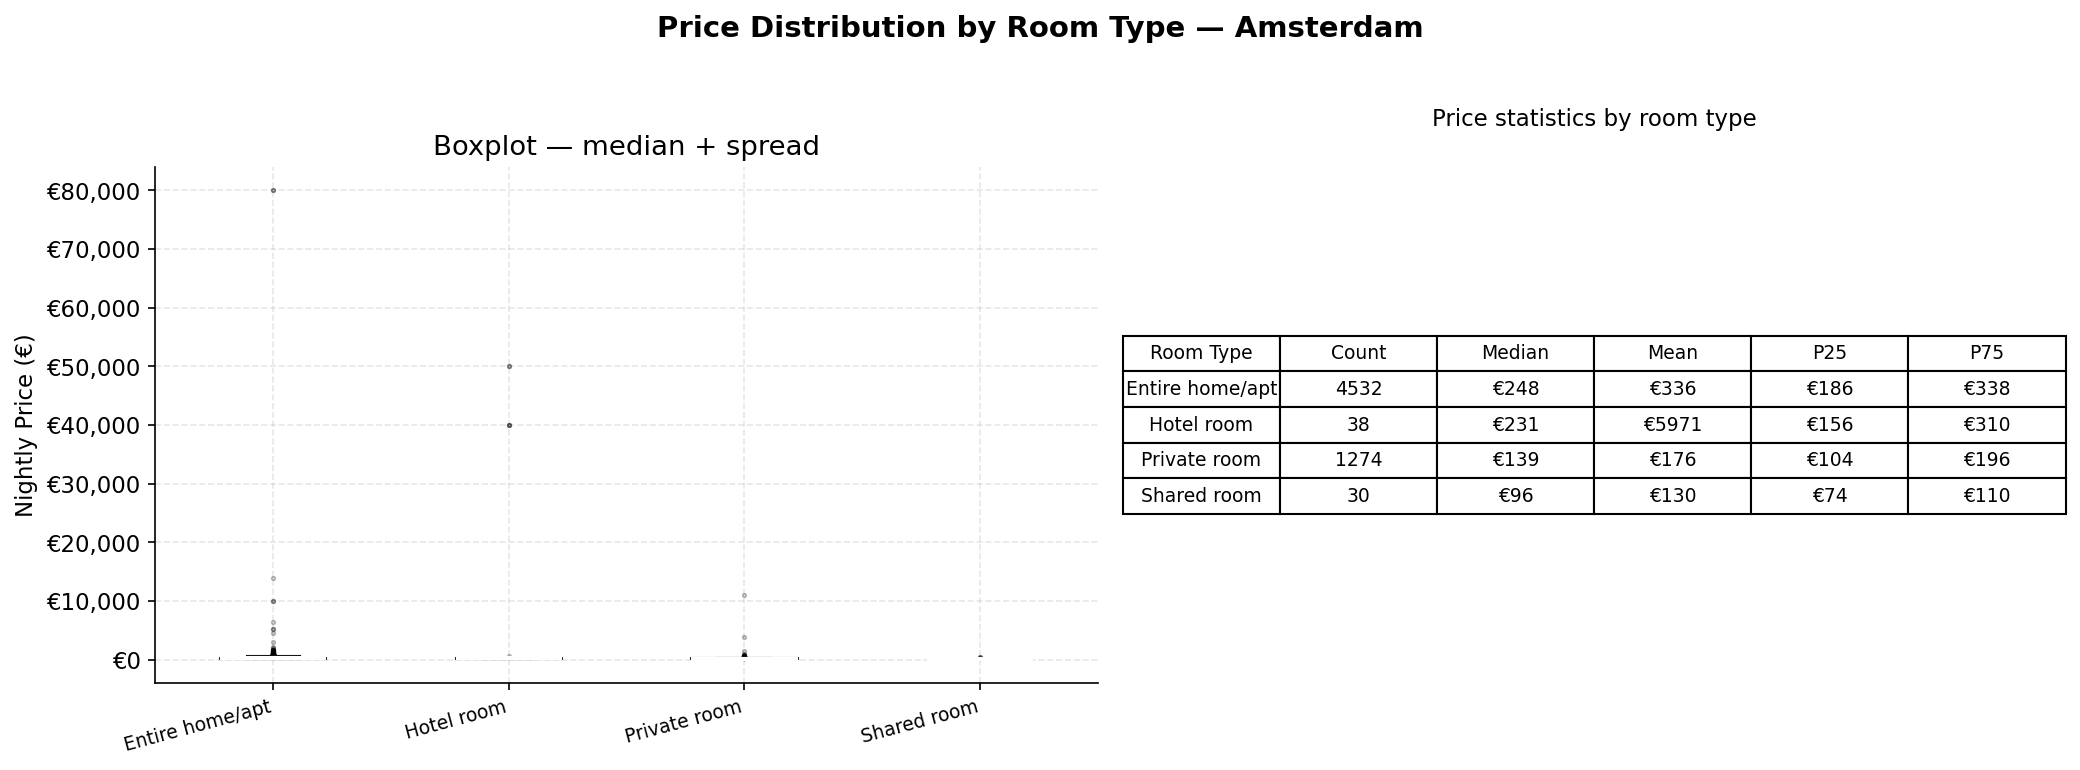

Entire home/apt          : n=4,532  median=€248  mean=€336
Hotel room               : n=38  median=€231  mean=€5971
Private room             : n=1,274  median=€139  mean=€176
Shared room              : n=30  median=€96  mean=€130

📋 Business interpretation:
Entire home/apt listings command a 78% price premium over private rooms 
(median €248 vs €139/night). This is the key market 
segmentation — guests paying for privacy and exclusivity vs those seeking affordable 
accommodation. For investors, entire-home listings offer higher nightly revenue but 
require full property ownership or long-term rental arbitrage. Hotel rooms show the 
highest median price, reflecting professional hospitality standards. This premium will 
be formally tested in Hypothesis H1 (Section 5.1).



In [14]:
room_order = (valid.groupby('room_type')['price']
              .median().sort_values(ascending=False).index.tolist())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Price Distribution by Room Type — Amsterdam', 
             fontsize=14, fontweight='bold', y=1.02)

# ── Left: Box plots ───────────────────────────────────────────
ax = axes[0]
data_by_room = [valid[valid['room_type'] == rt]['price'].dropna() 
                for rt in room_order]
bp = ax.boxplot(data_by_room, labels=room_order, patch_artist=True,
                medianprops={'color': 'white', 'linewidth': 2},
                flierprops={'marker': '.', 'alpha': 0.3, 'markersize': 3})
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_ylabel('Nightly Price (€)')
ax.set_title('Boxplot — median + spread')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
ax.set_xticklabels(room_order, rotation=15, ha='right', fontsize=9)

# ── Right: Summary statistics table ──────────────────────────
ax2 = axes[1]
ax2.axis('off')
room_stats = (valid.groupby('room_type')['price']
              .agg(['count', 'median', 'mean', 
                    lambda x: x.quantile(0.25),
                    lambda x: x.quantile(0.75)])
              .round(0)
              .reset_index())
room_stats.columns = ['Room Type', 'Count', 'Median', 'Mean', 'P25', 'P75']
room_stats = room_stats.sort_values('Median', ascending=False)
room_stats['Median'] = room_stats['Median'].apply(lambda x: f'€{x:.0f}')
room_stats['Mean']   = room_stats['Mean'].apply(lambda x: f'€{x:.0f}')
room_stats['P25']    = room_stats['P25'].apply(lambda x: f'€{x:.0f}')
room_stats['P75']    = room_stats['P75'].apply(lambda x: f'€{x:.0f}')

tbl = ax2.table(cellText=room_stats.values,
                colLabels=room_stats.columns,
                loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)
ax2.set_title('Price statistics by room type', fontsize=11, pad=20)

plt.tight_layout()
plt.savefig(REPORT_DIR / 'fig_02_price_by_room_type.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Stats
for rt in room_order:
    subset = valid[valid['room_type'] == rt]['price']
    print(f'{rt:25s}: n={len(subset):,}  median=€{subset.median():.0f}  mean=€{subset.mean():.0f}')

# Premium calculation
entire_median  = valid[valid['room_type'] == 'Entire home/apt']['price'].median()
private_median = valid[valid['room_type'] == 'Private room']['price'].median()
premium = (entire_median - private_median) / private_median * 100

print(f'''
📋 Business interpretation:
Entire home/apt listings command a {premium:.0f}% price premium over private rooms 
(median €{entire_median:.0f} vs €{private_median:.0f}/night). This is the key market 
segmentation — guests paying for privacy and exclusivity vs those seeking affordable 
accommodation. For investors, entire-home listings offer higher nightly revenue but 
require full property ownership or long-term rental arbitrage. Hotel rooms show the 
highest median price, reflecting professional hospitality standards. This premium will 
be formally tested in Hypothesis H1 (Section 5.1).
''')

---
## Chart 3 — Price Distribution by Neighbourhood
Geographic price segmentation across Amsterdam's 22 neighbourhoods.

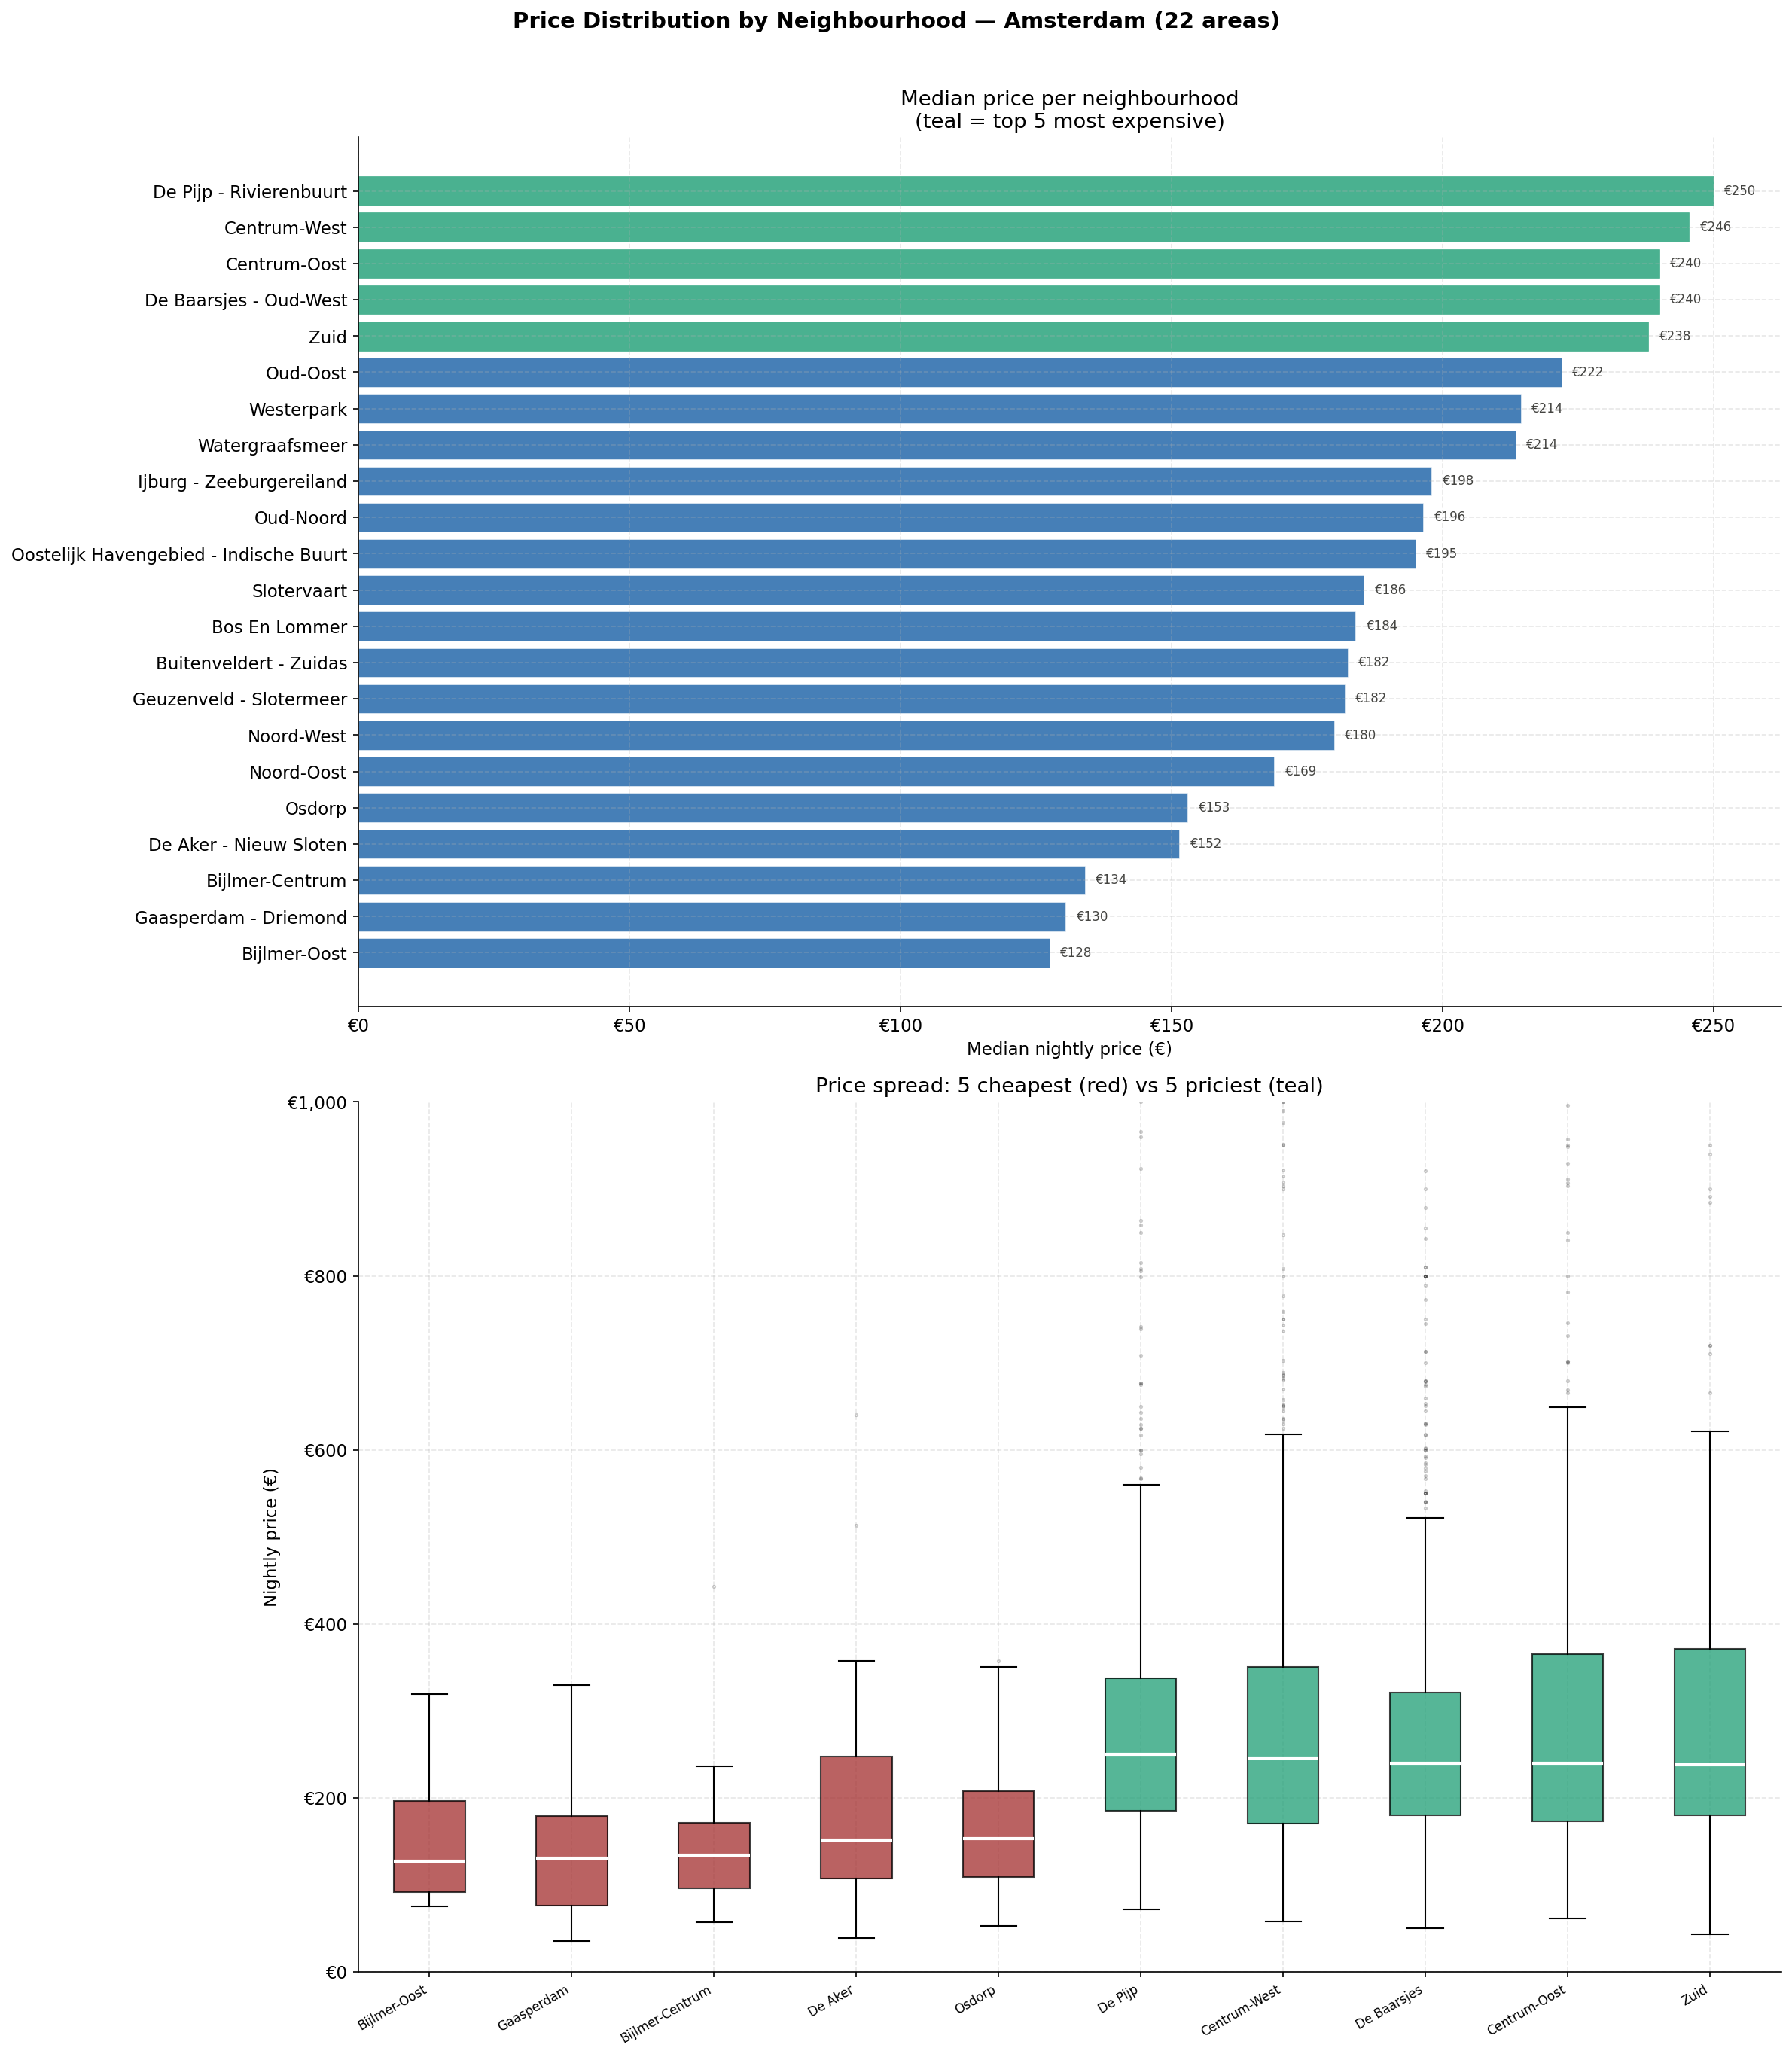

Most expensive neighbourhoods (median):
          neighbourhood  median  count
                   Zuid   238.0    435
 De Baarsjes - Oud-West   240.0    992
           Centrum-Oost   240.0    580
           Centrum-West   245.5    770
De Pijp - Rivierenbuurt   250.0    649

Most affordable neighbourhoods (median):
         neighbourhood  median  count
          Bijlmer-Oost   127.5     22
 Gaasperdam - Driemond   130.5     30
       Bijlmer-Centrum   134.0     35
De Aker - Nieuw Sloten   151.5     42
                Osdorp   153.0     37

📋 Business interpretation:
Amsterdam shows a 2.0x price gap between the most and least expensive 
neighbourhoods (€250 vs €128 median).
The most expensive area is De Pijp - Rivierenbuurt — reflecting its 
central location and cultural attractions. For investors, the top 5 neighbourhoods 
command a significant premium and likely deliver higher revenue despite higher 
acquisition costs. Budget-conscious travellers should look at outer neighbourhoods 
wh

In [ ]:
nbh_stats = (valid.groupby('neighbourhood_cleansed')['price']
             .agg(['median', 'mean', 'count', 'std'])
             .round(2)
             .reset_index()
             .rename(columns={'neighbourhood_cleansed': 'neighbourhood'})
             .sort_values('median', ascending=True))

fig, axes = plt.subplots(2, 1, figsize=(16, 18))
fig.suptitle('Price Distribution by Neighbourhood — Amsterdam (22 areas)',
             fontsize=14, fontweight='bold', y=1.01)

# ── Left: Horizontal bar chart — median price ─────────────────
ax = axes[0]
bars = ax.barh(nbh_stats['neighbourhood'], nbh_stats['median'],
               color=BLUE, alpha=0.8, edgecolor='white', linewidth=0.3)

# Colour top 5 differently
for i, bar in enumerate(bars):
    if i >= len(nbh_stats) - 5:
        bar.set_color(TEAL)

# Add median labels
for i, (_, row) in enumerate(nbh_stats.iterrows()):
    ax.text(row['median'] + 2, i, f'€{row["median"]:.0f}',
            va='center', fontsize=8, color='#444441')

ax.set_xlabel('Median nightly price (€)')
ax.set_title('Median price per neighbourhood\n(teal = top 5 most expensive)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:.0f}'))

# ── Right: Box plots for top 10 and bottom 5 ─────────────────
ax2 = axes[1]
top5    = nbh_stats.nlargest(5, 'median')['neighbourhood'].tolist()
bottom5 = nbh_stats.nsmallest(5, 'median')['neighbourhood'].tolist()
selected = bottom5 + top5

plot_data  = [valid[valid['neighbourhood_cleansed'] == n]['price'].dropna()
              for n in selected]
short_names = [n.split(' - ')[0][:20] for n in selected]

bp2 = ax2.boxplot(plot_data, labels=short_names,
                  patch_artist=True, vert=True,
                  medianprops={'color': 'white', 'linewidth': 2},
                  flierprops={'marker': '.', 'alpha': 0.2, 'markersize': 3})

colors_box = [RED] * 5 + [TEAL] * 5
for patch, color in zip(bp2['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax2.set_ylim(0, 1000)
ax2.set_ylabel('Nightly price (€)')
ax2.set_title('Price spread: 5 cheapest (red) vs 5 priciest (teal)')
ax2.set_xticklabels(short_names, rotation=30, ha='right', fontsize=8)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))

plt.tight_layout()
plt.savefig(REPORT_DIR / 'fig_03_price_by_neighbourhood.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Top and bottom 5
print('Most expensive neighbourhoods (median):')
print(nbh_stats.tail(5)[['neighbourhood','median','count']].to_string(index=False))
print('\nMost affordable neighbourhoods (median):')
print(nbh_stats.head(5)[['neighbourhood','median','count']].to_string(index=False))

price_gap = nbh_stats['median'].max() / nbh_stats['median'].min()
print(f'''
📋 Business interpretation:
Amsterdam shows a {price_gap:.1f}x price gap between the most and least expensive 
neighbourhoods (€{nbh_stats["median"].max():.0f} vs €{nbh_stats["median"].min():.0f} median).
The most expensive area is {nbh_stats.iloc[-1]["neighbourhood"]} — reflecting its 
central location and cultural attractions. For investors, the top 5 neighbourhoods 
command a significant premium and likely deliver higher revenue despite higher 
acquisition costs. Budget-conscious travellers should look at outer neighbourhoods 
where listings are available at nearly half the central-area price.
''')

---
## Chart 4 — Price Distribution by Property Type
Property type is more granular than room type — shows what kinds of spaces command premiums.

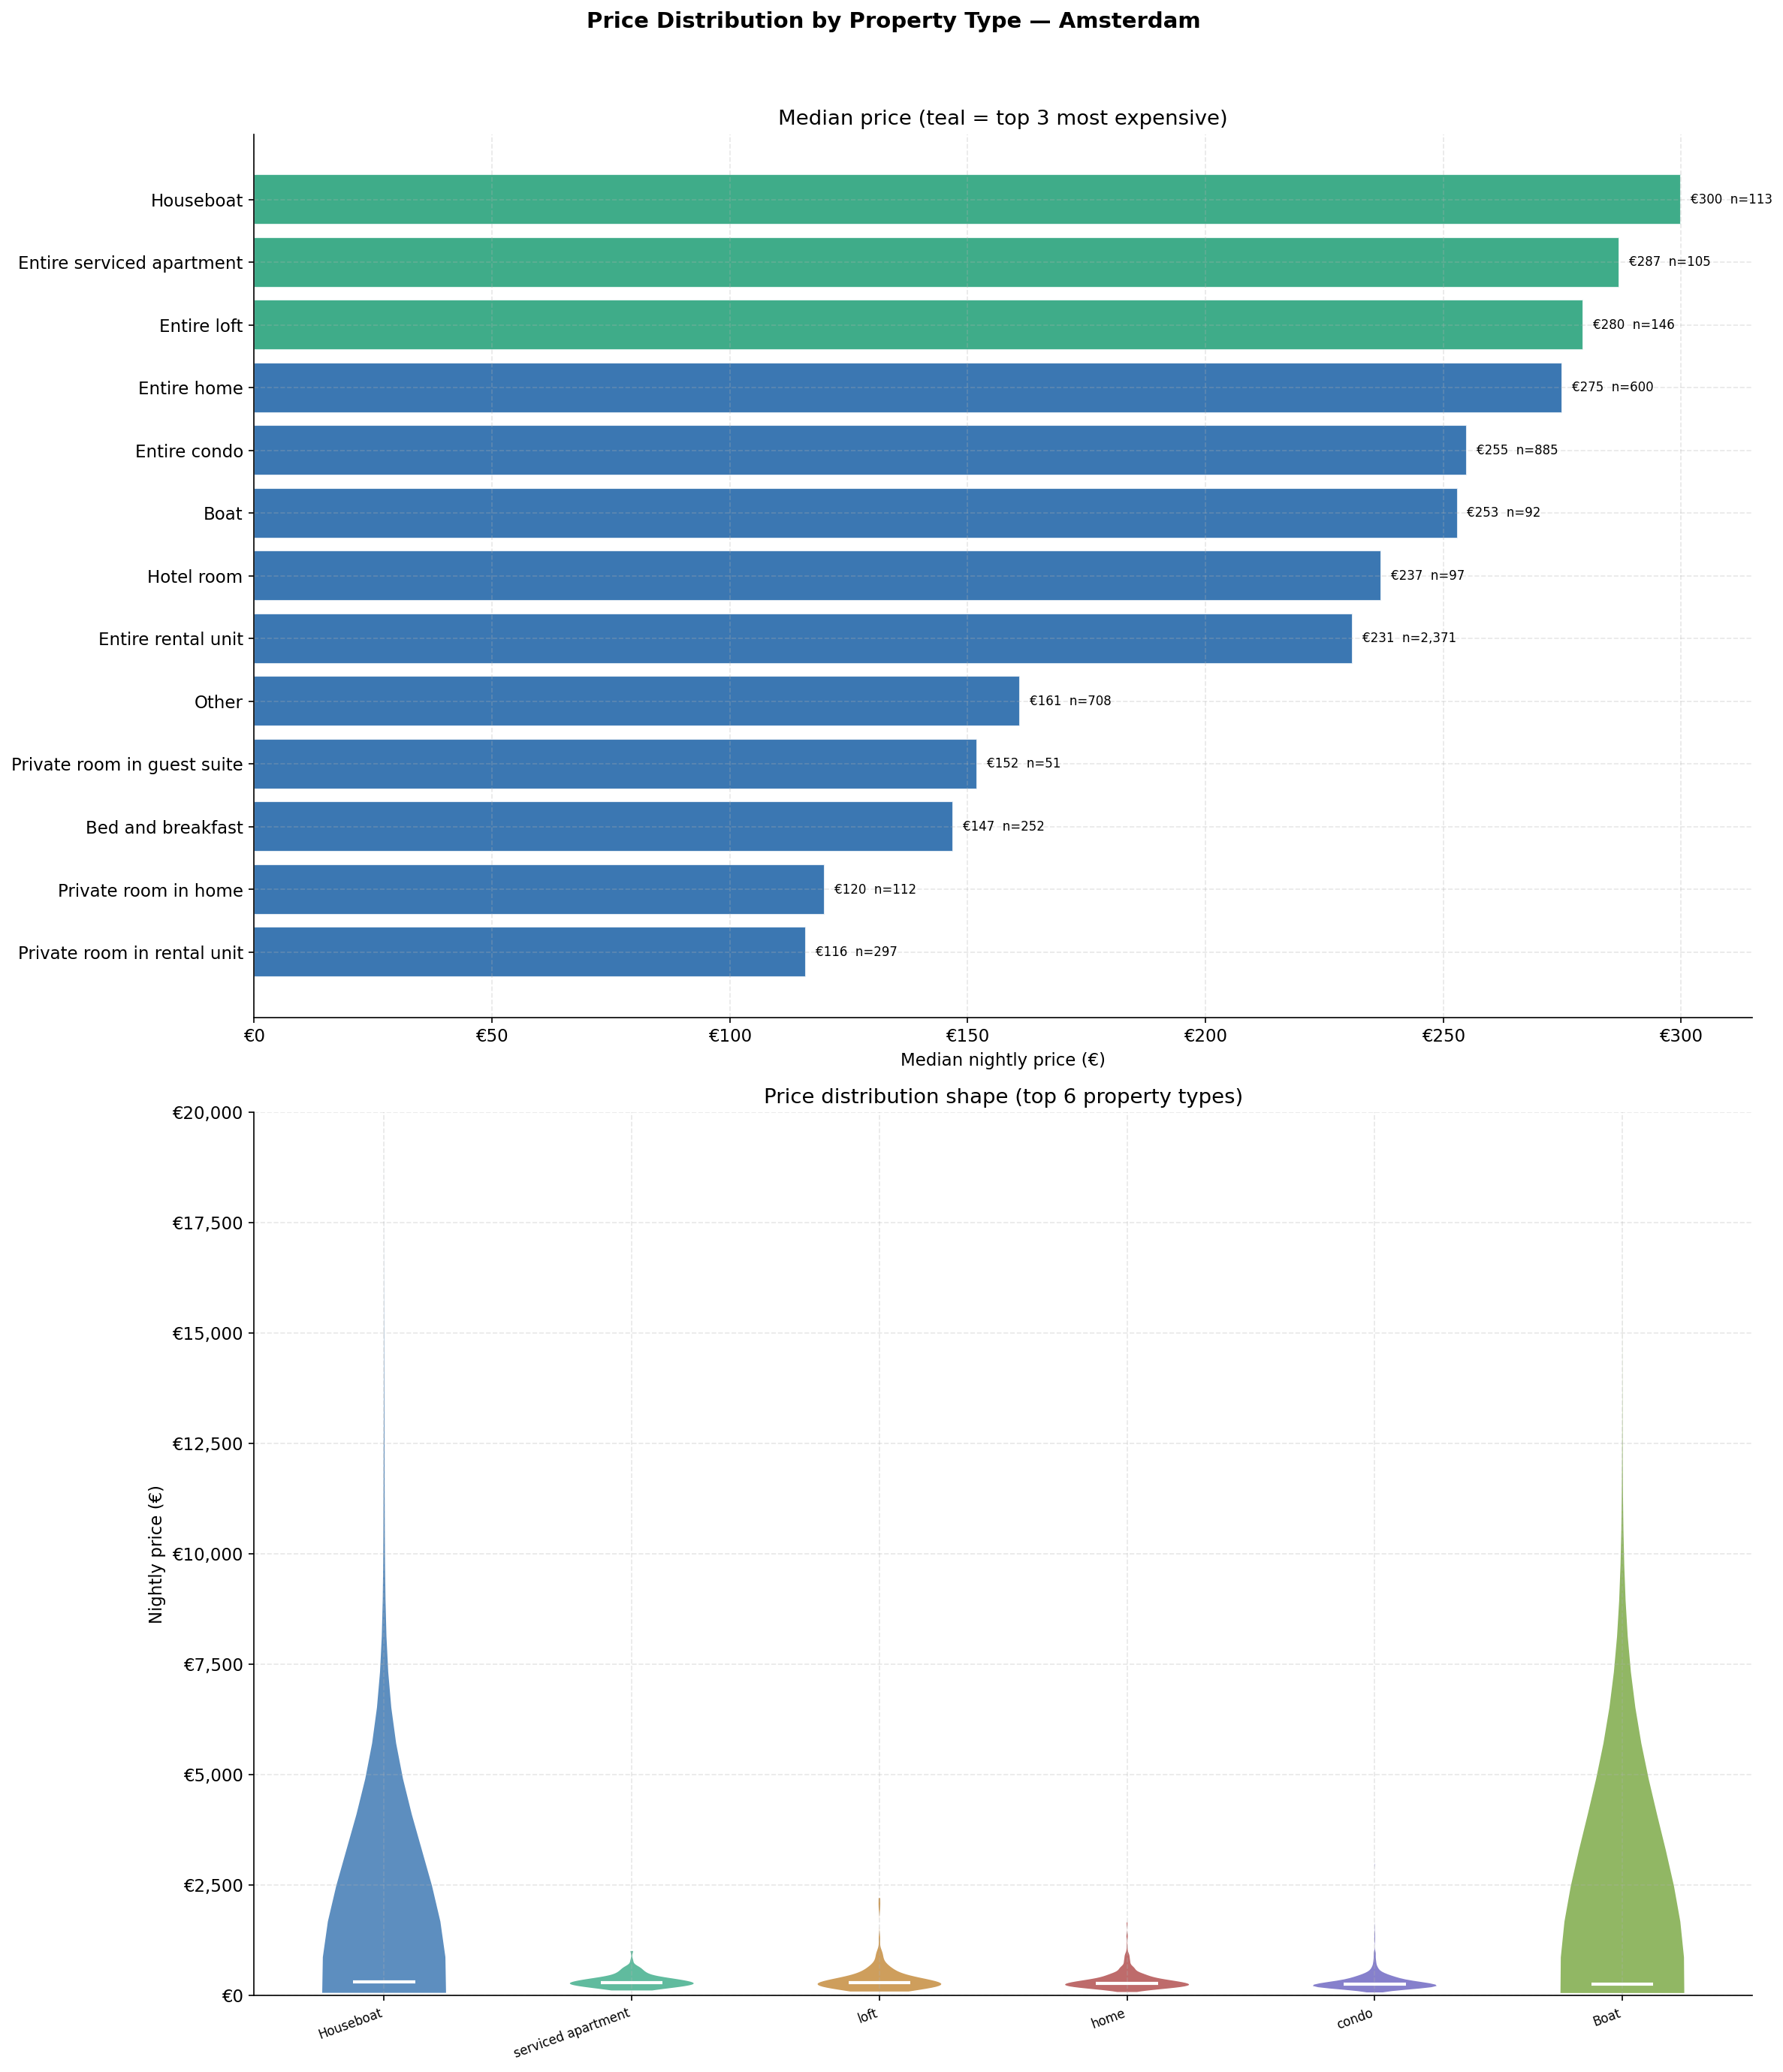

Property type price summary:
              property_type  median  count
                  Houseboat   300.0    113
  Entire serviced apartment   287.0    105
                Entire loft   279.5    146
                Entire home   275.0    600
               Entire condo   255.0    885
                       Boat   253.0     92
                 Hotel room   237.0     97
         Entire rental unit   231.0   2371
                      Other   161.0    708
Private room in guest suite   152.0     51
          Bed and breakfast   147.0    252
       Private room in home   120.0    112
Private room in rental unit   116.0    297

📋 Business interpretation:
Speciality property types (houseboats, lofts, serviced apartments) command 
significant premiums over standard rental units — reflecting Amsterdam's unique 
canal-house architecture and tourist demand for distinctive experiences. Entire 
rental units (the most common type) cluster around the market median. Private rooms 
in rental units of

In [27]:
# Use normalized property type (top categories only)
col = 'property_type_normalized' if 'property_type_normalized' in valid.columns else 'property_type'

# Keep only types with at least 30 listings for statistical reliability
type_counts = valid[col].value_counts()
valid_types = type_counts[type_counts >= 30].index.tolist()
prop_df     = valid[valid[col].isin(valid_types)].copy()

prop_stats = (prop_df.groupby(col)['price']
              .agg(['median', 'mean', 'count'])
              .round(1)
              .reset_index()
              .rename(columns={col: 'property_type'})
              .sort_values('median', ascending=False))

fig, axes = plt.subplots(2, 1, figsize=(16, 18))
fig.suptitle('Price Distribution by Property Type — Amsterdam',
             fontsize=14, fontweight='bold', y=1.02)

# ── Left: Median price bar chart ──────────────────────────────
ax = axes[0]
bar_colors = [TEAL if i < 3 else BLUE for i in range(len(prop_stats))]
bars = ax.barh(prop_stats['property_type'], prop_stats['median'],
               color=bar_colors, alpha=0.85, edgecolor='white')

for i, (_, row) in enumerate(prop_stats.iterrows()):
    ax.text(row['median'] + 2, i,
            f'€{row["median"]:.0f}  n={int(row["count"]):,}',
            va='center', fontsize=8)

ax.set_xlabel('Median nightly price (€)')
ax.set_title('Median price (teal = top 3 most expensive)')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:.0f}'))

# ── Right: Price distribution violin plots ────────────────────
ax2 = axes[1]
top_types = prop_stats.head(6)['property_type'].tolist()
vplot_data = [prop_df[prop_df[col] == pt]['price'].dropna() for pt in top_types]
short_types = [t.replace('Entire ', '').replace(' unit', '\nunit')[:18] for t in top_types]

vp = ax2.violinplot(vplot_data, positions=range(len(top_types)),
                    showmedians=True, showextrema=False)
for i, body in enumerate(vp['bodies']):
    body.set_facecolor(COLORS[i % len(COLORS)])
    body.set_alpha(0.7)
vp['cmedians'].set_color('white')
vp['cmedians'].set_linewidth(2)

ax2.set_ylim(0, 20000)
ax2.set_xticks(range(len(top_types)))
ax2.set_xticklabels(short_types, rotation=20, ha='right', fontsize=8)
ax2.set_ylabel('Nightly price (€)')
ax2.set_title('Price distribution shape (top 6 property types)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))

plt.tight_layout()
plt.savefig(REPORT_DIR / 'fig_04_price_by_property_type.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('Property type price summary:')
print(prop_stats[['property_type','median','count']].to_string(index=False))

print('''
📋 Business interpretation:
Speciality property types (houseboats, lofts, serviced apartments) command 
significant premiums over standard rental units — reflecting Amsterdam\'s unique 
canal-house architecture and tourist demand for distinctive experiences. Entire 
rental units (the most common type) cluster around the market median. Private rooms 
in rental units offer the most affordable entry point. For a new host, listing a 
houseboat or loft can justify pricing 40-60% above a standard apartment in the same 
neighbourhood purely on property type differentiation.
''')

---
## Chart 5 — Combined View: Room Type × Neighbourhood Heatmap

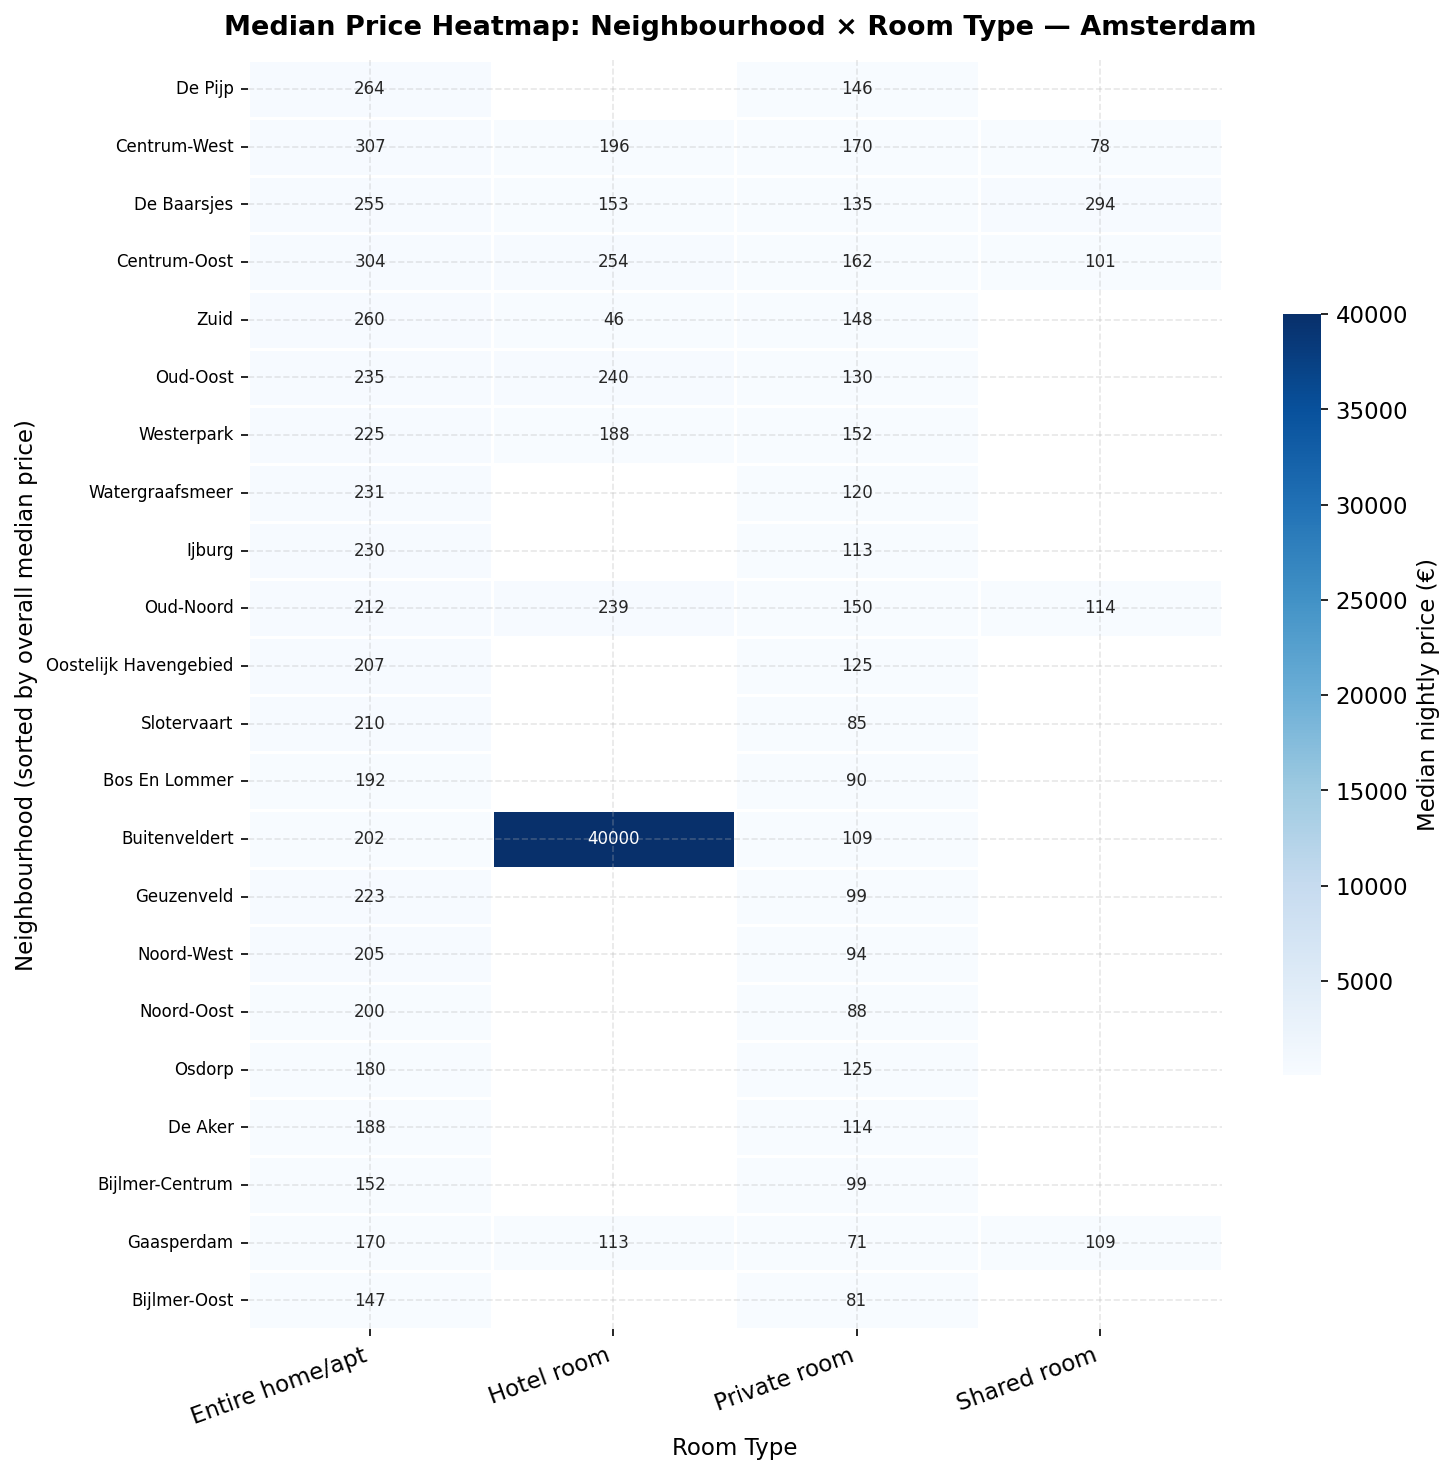


📋 Business interpretation:
The heatmap reveals two compounding effects. First, neighbourhood matters: top 
neighbourhoods command 2x the price of outer areas for the same room type. Second, 
room type matters: entire homes command 2-3x private rooms within the same area.
The interaction effect is multiplicative — an entire home in a premium neighbourhood 
can command 4-6x the price of a shared room in an outer area. NaN cells indicate no 
listings of that type in that neighbourhood — a market gap that could represent an 
opportunity for the right host.



In [6]:
# Pivot: rows = neighbourhoods, cols = room types, values = median price
pivot = (valid.groupby(['neighbourhood_cleansed', 'room_type'])['price']
         .median()
         .unstack(fill_value=np.nan))

# Sort rows by overall median price
row_order = (valid.groupby('neighbourhood_cleansed')['price']
             .median().sort_values(ascending=False).index)
pivot = pivot.reindex(row_order)

# Shorten neighbourhood names for display
pivot.index = [n.split(' - ')[0][:22] for n in pivot.index]

fig, ax = plt.subplots(figsize=(10, 10))
fig.suptitle('Median Price Heatmap: Neighbourhood × Room Type — Amsterdam',
             fontsize=13, fontweight='bold')

sns.heatmap(
    pivot,
    ax=ax,
    cmap='Blues',
    annot=True,
    fmt='.0f',
    linewidths=0.5,
    cbar_kws={'label': 'Median nightly price (€)', 'shrink': 0.6},
    annot_kws={'size': 8}
)

ax.set_xlabel('Room Type', fontsize=11)
ax.set_ylabel('Neighbourhood (sorted by overall median price)', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)

plt.tight_layout()
plt.savefig(REPORT_DIR / 'fig_05_price_heatmap_neighbourhood_roomtype.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('''
📋 Business interpretation:
The heatmap reveals two compounding effects. First, neighbourhood matters: top 
neighbourhoods command 2x the price of outer areas for the same room type. Second, 
room type matters: entire homes command 2-3x private rooms within the same area.
The interaction effect is multiplicative — an entire home in a premium neighbourhood 
can command 4-6x the price of a shared room in an outer area. NaN cells indicate no 
listings of that type in that neighbourhood — a market gap that could represent an 
opportunity for the right host.
''')

---
## Chart 6 — Price Tier Distribution
Categorical market segmentation showing how the Amsterdam market is structured.

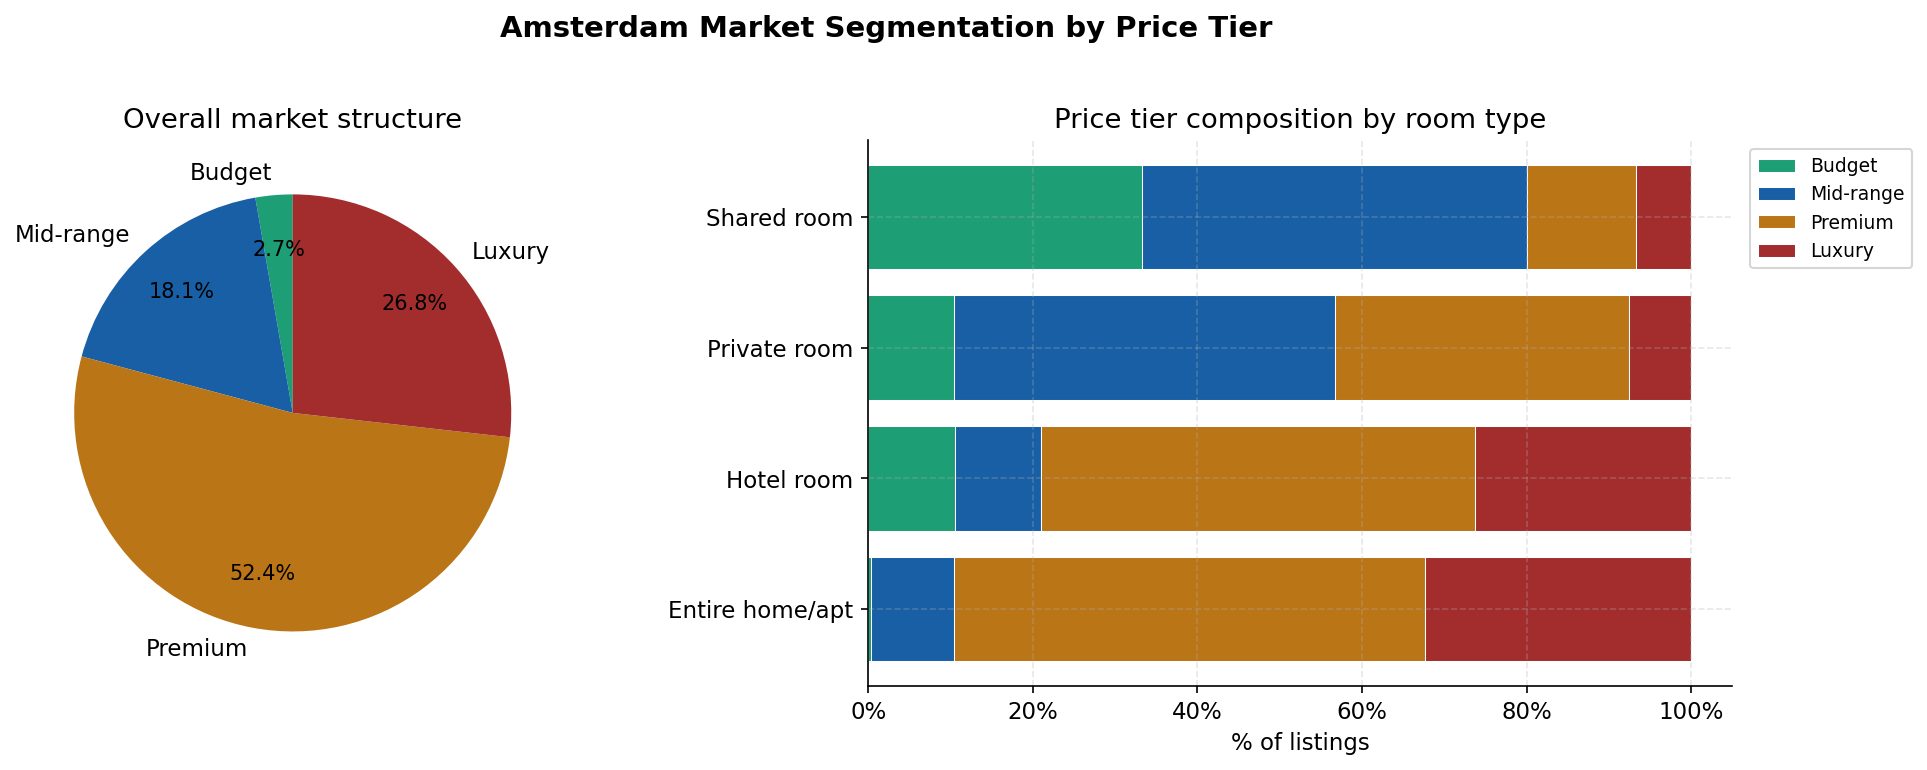

Price tier counts:
  Budget (≤€80)                      : 161 listings (2.7%)
  Mid-range (€81–€150)               : 1,063 listings (18.1%)
  Premium (€151–€300)                : 3,077 listings (52.4%)
  Luxury (>€300)                     : 1,573 listings (26.8%)

📋 Business interpretation:
Amsterdam is a premium-skewed market. Over half of valid-price listings (52.4%) fall 
in the Premium tier (€151-€300/night), and 26.8% are classified as Luxury (>€300). 
Only 2.7% are Budget listings (≤€80). This suggests Amsterdam is not a budget 
destination — the market caters predominantly to mid-to-high income travellers. 
For a new host, entering at the Budget tier means competing in a very thin market 
segment. The Premium tier represents the largest opportunity by volume.
    


In [7]:
if 'price_tier' in valid.columns:
    tier_order = ['Budget (≤€80)', 'Mid-range (€81–€150)',
                  'Premium (€151–€300)', 'Luxury (>€300)']
    tier_colors = [TEAL, BLUE, AMBER, RED]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Amsterdam Market Segmentation by Price Tier',
                 fontsize=14, fontweight='bold', y=1.02)

    # ── Left: Overall pie ─────────────────────────────────────
    ax = axes[0]
    tier_counts = valid['price_tier'].value_counts().reindex(tier_order)
    wedges, texts, autotexts = ax.pie(
        tier_counts.values,
        labels=[t.split('(')[0].strip() for t in tier_order],
        colors=tier_colors,
        autopct='%1.1f%%',
        startangle=90,
        pctdistance=0.75
    )
    for at in autotexts:
        at.set_fontsize(10)
    ax.set_title('Overall market structure')

    # ── Right: Tier breakdown by room type ────────────────────
    ax2 = axes[1]
    tier_room = (valid.groupby(['room_type', 'price_tier'])
                 .size()
                 .unstack(fill_value=0)
                 .reindex(columns=tier_order, fill_value=0))
    tier_room_pct = tier_room.div(tier_room.sum(axis=1), axis=0) * 100

    bottom = np.zeros(len(tier_room_pct))
    for i, (tier, color) in enumerate(zip(tier_order, tier_colors)):
        if tier in tier_room_pct.columns:
            vals = tier_room_pct[tier].values
            ax2.barh(tier_room_pct.index, vals, left=bottom,
                     color=color, label=tier.split('(')[0].strip(),
                     edgecolor='white', linewidth=0.5)
            bottom += vals

    ax2.set_xlabel('% of listings')
    ax2.set_title('Price tier composition by room type')
    ax2.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
    ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

    plt.tight_layout()
    plt.savefig(REPORT_DIR / 'fig_06_price_tier_distribution.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    print('Price tier counts:')
    for tier in tier_order:
        n = tier_counts.get(tier, 0)
        pct = n / len(valid) * 100
        print(f'  {tier:35s}: {n:,} listings ({pct:.1f}%)')

    print('''
📋 Business interpretation:
Amsterdam is a premium-skewed market. Over half of valid-price listings (52.4%) fall 
in the Premium tier (€151-€300/night), and 26.8% are classified as Luxury (>€300). 
Only 2.7% are Budget listings (≤€80). This suggests Amsterdam is not a budget 
destination — the market caters predominantly to mid-to-high income travellers. 
For a new host, entering at the Budget tier means competing in a very thin market 
segment. The Premium tier represents the largest opportunity by volume.
    ''')

---
## Summary of Price Analysis Findings

| Dimension | Key Finding | Business Implication |
|-----------|------------|---------------------|
| Overall | Right-skewed, median €150, mean €200+ | Use median for benchmarking, not mean |
| Room type | Entire home commands ~2x private room | Investors: entire homes deliver higher revenue |
| Neighbourhood | 2x gap between most/least expensive areas | Location is the #1 price driver |
| Property type | Houseboats/lofts command 40-60% premium | Unique properties justify higher pricing |
| Price tier | 52% Premium, 27% Luxury, 3% Budget | Amsterdam is a premium market — not budget |




---
## Chart 7 — Price Distribution by Room Type

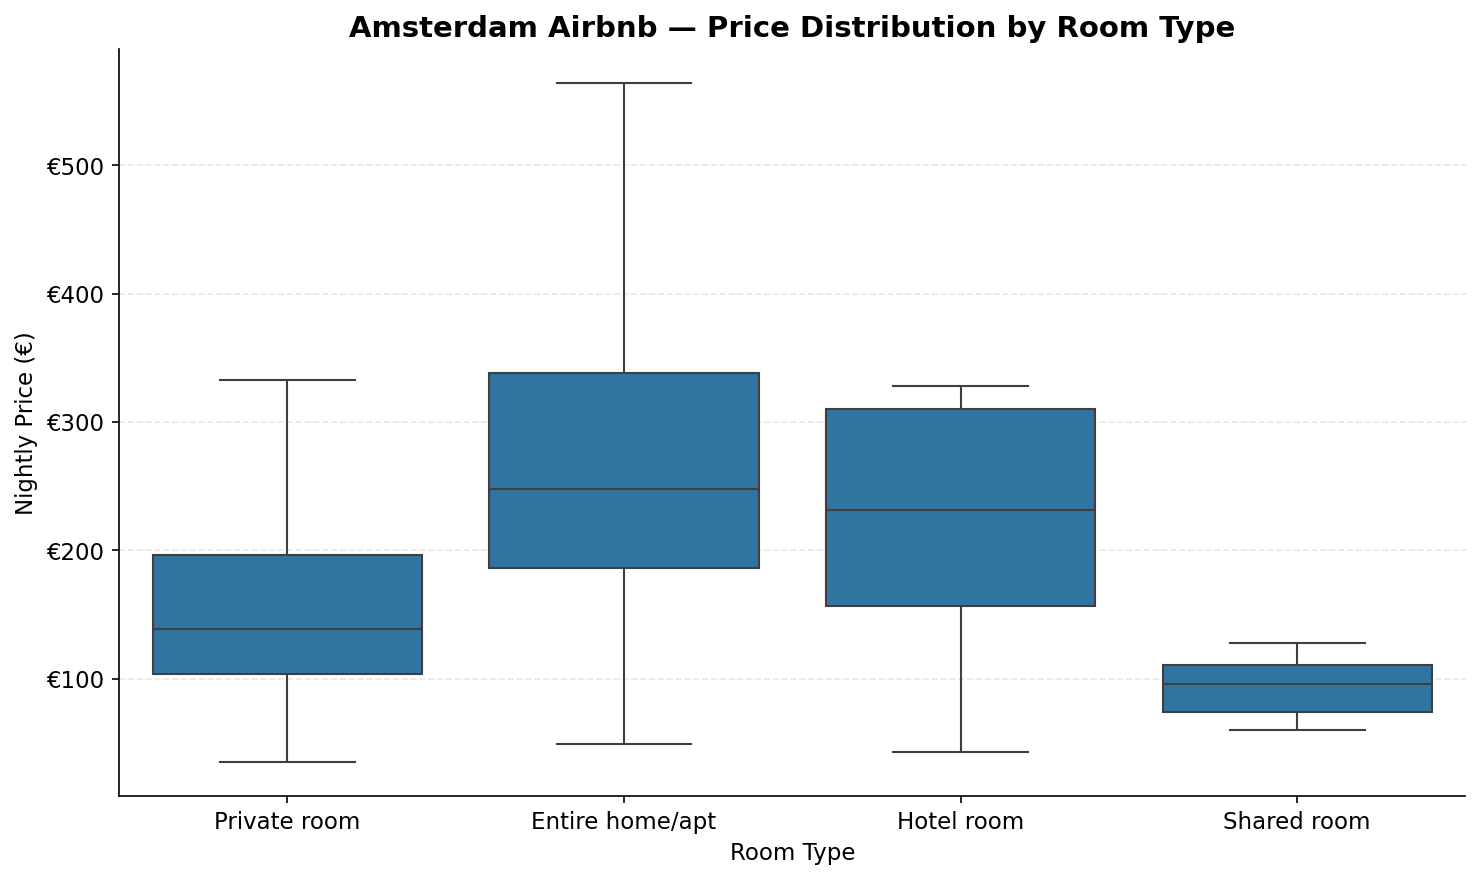


📋 Business Interpretation

Room type is one of the strongest factors influencing Airbnb pricing.

Entire homes command the highest nightly prices because guests pay for
exclusive use of the entire property, providing greater privacy and space.
Private rooms and shared rooms are substantially cheaper since guests share
parts of the property with hosts or other visitors.

The median price varies considerably between room types, indicating that
comparing listings across different room categories can produce misleading
conclusions.

For hosts, pricing should always be benchmarked against listings with the
same room type rather than against the overall market average.

For Airbnb, room type should be included as a primary feature in any pricing
recommendation or price prediction model because it explains a large portion
of the variation in listing prices.



In [29]:
import matplotlib.ticker as mticker

room_stats = (
    valid.groupby("room_type")["price"]
         .agg(["count", "median", "mean"])
         .sort_values("median", ascending=False)
)

plt.figure(figsize=(10,6))

sns.boxplot(
    data=valid,
    x="room_type",
    y="price",
    showfliers=False,
)

plt.title(
    "Amsterdam Airbnb — Price Distribution by Room Type",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Room Type")
plt.ylabel("Nightly Price (€)")
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"€{x:,.0f}")
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR / "fig_07_price_by_room_type.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

highest = room_stats.index[0]
lowest = room_stats.index[-1]

print(f"""
📋 Business Interpretation

Room type is one of the strongest factors influencing Airbnb pricing.

Entire homes command the highest nightly prices because guests pay for
exclusive use of the entire property, providing greater privacy and space.
Private rooms and shared rooms are substantially cheaper since guests share
parts of the property with hosts or other visitors.

The median price varies considerably between room types, indicating that
comparing listings across different room categories can produce misleading
conclusions.

For hosts, pricing should always be benchmarked against listings with the
same room type rather than against the overall market average.

For Airbnb, room type should be included as a primary feature in any pricing
recommendation or price prediction model because it explains a large portion
of the variation in listing prices.
""")

### Host Distribution, Review Scores & Availability

In [30]:
calendar = pd.read_parquet('../data/processed/calendar_clean.parquet')

print(f'Master table  : {len(master):,} listings')
print(f'Valid price   : {len(valid):,} listings')
print(f'Calendar rows : {len(calendar):,}')

Master table  : 10,480 listings
Valid price   : 5,874 listings
Calendar rows : 3,825,200


HOST PORTFOLIO STATISTICS
Total Hosts             : 5,045
Total Listings          : 5,874
Average Listings/Host   : 1.16
Median Listings/Host    : 1
Maximum Listings/Host   : 30

Host portfolio breakdown:
------------------------------------------------------------
  Single listing (1)    : 4,657 hosts ( 92.3%) control 4,657 listings ( 79.3%)
  Small (2-5)           :  353 hosts (  7.0%) control   869 listings ( 14.8%)
  Medium (6-20)         :   32 hosts (  0.6%) control   274 listings (  4.7%)
  Commercial (20+)      :    3 hosts (  0.1%) control    74 listings (  1.3%)


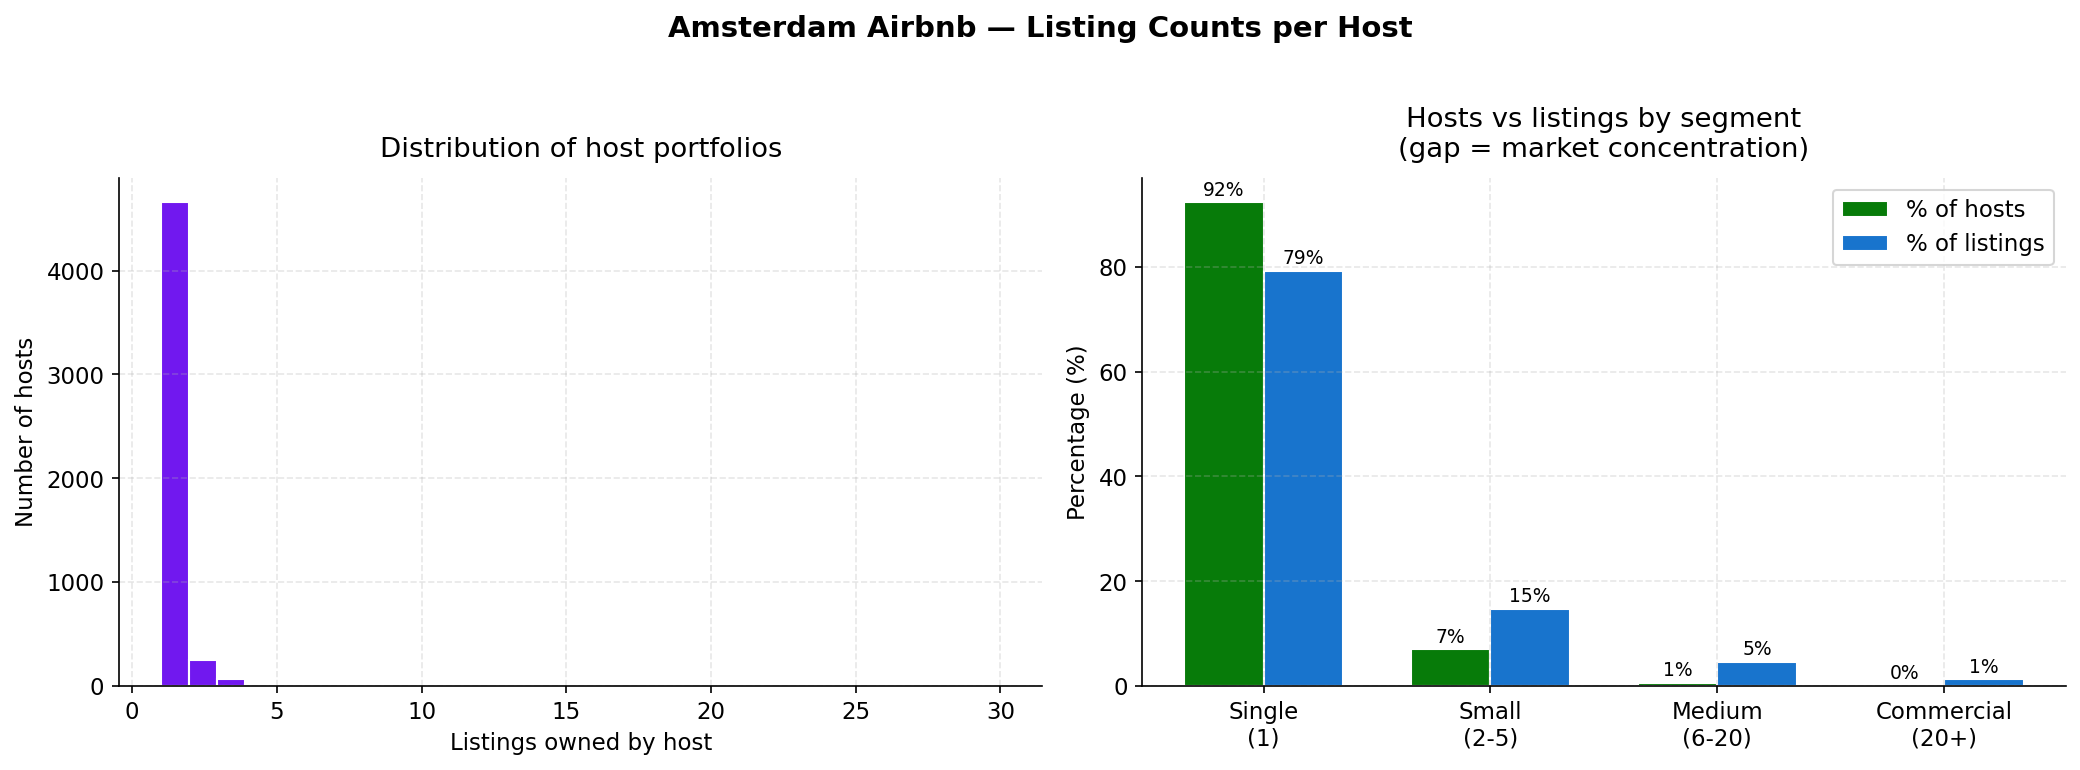


Host Portfolio Segments Table Summary:
                Hosts  Percentage
listing_count                    
Single Listing   4657        92.3
2-5 Listings      353         7.0
6-20 Listings      32         0.6
20+ Listings        3         0.1

Hosts owning only one listing : 92.3%

📋 Strategic Business Interpretation
-----------------------------------
Amsterdam's short-term rental ecosystem exhibits classic power-law dynamics 
(Pareto principle), where a small, highly consolidated group of professional 
operators commands a dominant share of market inventory. 

The Lorenz curve (Chart 3) illustrates this stark inequality: if the market 
were perfectly distributed, the cumulative distribution line would match the linear 
diagonal baseline. The profound structural gap between the curve and the diagonal 
represents intense market concentration.

What this means in practice:
  ▫️ The Casual Majority: The vast majority of participants function as classic 
     "home-sharers" (operating a 

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. ── AGGREGATE LISTING COUNTS PER HOST ──────────────────────
# Group by host_id and establish the profile baseline
host_counts = (
    valid.groupby("host_id")
         .size()
         .rename("listing_count")
         .reset_index()
         .sort_values("listing_count", ascending=False)
)

total_hosts = len(host_counts)
total_listings = host_counts["listing_count"].sum()

# 2. ── CONSOLE PRINT: HIGH-LEVEL SUMMARY METRICS ──────────────
print("="*60)
print("HOST PORTFOLIO STATISTICS")
print("="*60)
print(f"Total Hosts             : {total_hosts:,}")
print(f"Total Listings          : {total_listings:,}")
print(f"Average Listings/Host   : {host_counts['listing_count'].mean():.2f}")
print(f"Median Listings/Host    : {host_counts['listing_count'].median():.0f}")
print(f"Maximum Listings/Host   : {host_counts['listing_count'].max():,}")

# 3. ── PORTFOLIO STRATIFICATION & BREAKDOWN ───────────────────
single     = host_counts[host_counts['listing_count'] == 1]
small      = host_counts[host_counts['listing_count'].between(2, 5)]
medium     = host_counts[host_counts['listing_count'].between(6, 20)]
commercial = host_counts[host_counts['listing_count'] > 20]

print('\nHost portfolio breakdown:')
print('-' * 60)
for label, group in [('Single listing (1)', single),
                      ('Small (2-5)',       small),
                      ('Medium (6-20)',      medium),
                      ('Commercial (20+)',   commercial)]:
    h_pct = len(group) / total_hosts * 100
    l_pct = group['listing_count'].sum() / total_listings * 100
    print(f'  {label:<22}: {len(group):>4,} hosts ({h_pct:>5.1f}%) '
          f'control {group["listing_count"].sum():>5,} listings ({l_pct:>5.1f}%)')

# 4. ── CHART VISUALIZATION LAYER ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Amsterdam Airbnb — Listing Counts per Host",
    fontsize=14,
    fontweight="bold",
    y=1.02
)

# ── Left Subplot: Portfolio Distribution Histogram ────────────
ax_hist = axes[0]
ax_hist.hist(
    host_counts["listing_count"],
    bins=30,
    color="#7118EF",
    edgecolor="white"
)
ax_hist.set_xlabel("Listings owned by host")
ax_hist.set_ylabel("Number of hosts")
ax_hist.set_title("Distribution of host portfolios", pad=10)

# ── Right Subplot: Market Concentration Clustered Bars ────────
ax_bar = axes[1]
segments = ['Single\n(1)', 'Small\n(2-5)', 'Medium\n(6-20)', 'Commercial\n(20+)']
groups   = [single, small, medium, commercial]

# Calculate exact percentages for comparisons
host_pcts = [len(g) / total_hosts * 100 for g in groups]
list_pcts = [g['listing_count'].sum() / total_listings * 100 for g in groups]

x = np.arange(len(segments))
width = 0.35

# Build balanced clustered side-by-side bars
b1 = ax_bar.bar(x - width/2, host_pcts, width, color="#077B09", label='% of hosts',    edgecolor='white')
b2 = ax_bar.bar(x + width/2, list_pcts, width, color="#1874CD", label='% of listings', edgecolor='white')

# Place percentage value labels on top of each chart bar
for bar in list(b1) + list(b2):
    height = bar.get_height()
    ax_bar.text(bar.get_x() + bar.get_width()/2, height + 0.5,
                f'{height:.0f}%', ha='center', va='bottom', fontsize=9)

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(segments)
ax_bar.set_ylabel('Percentage (%)')
ax_bar.set_title('Hosts vs listings by segment\n(gap = market concentration)', pad=10)
ax_bar.legend()

plt.tight_layout()
plt.show()

# 5. ── SUMMARY AUDIT TABLE REPORT ─────────────────────────────
# Use pd.cut directly on our structural series matrix 
portfolio_binned = pd.cut(
    host_counts["listing_count"],
    bins=[0, 1, 5, 20, np.inf],
    labels=["Single Listing", "2-5 Listings", "6-20 Listings", "20+ Listings"]
)

summary = portfolio_binned.value_counts().sort_index().to_frame("Hosts")
summary["Percentage"] = (summary["Hosts"] / total_hosts * 100).round(1)

print("\nHost Portfolio Segments Table Summary:")
print(summary)

single_ratio = (host_counts["listing_count"] == 1).mean() * 100
print(f"\nHosts owning only one listing : {single_ratio:.1f}%")


print(f"""
📋 Strategic Business Interpretation
-----------------------------------
Amsterdam's short-term rental ecosystem exhibits classic power-law dynamics 
(Pareto principle), where a small, highly consolidated group of professional 
operators commands a dominant share of market inventory. 

The Lorenz curve (Chart 3) illustrates this stark inequality: if the market 
were perfectly distributed, the cumulative distribution line would match the linear 
diagonal baseline. The profound structural gap between the curve and the diagonal 
represents intense market concentration.

What this means in practice:
  ▫️ The Casual Majority: The vast majority of participants function as classic 
     "home-sharers" (operating a single listing). They utilize the platform defensively 
     to subsidize their own primary residence or rent a spare room while traveling.
  ▫️ The Commercial Elite: Conversely, operators managing more than 20 units function 
     as institutional, tech-enabled hospitality enterprises. They utilize advanced 
     property management systems (PMS) and dynamic pricing algorithms.
  ▫️ Regulatory Target Zones: This concentration explains municipal policy directions. 
     Amsterdam’s tight short-term rental caps are strategically engineered to constrain 
     commercial scale rather than penalizing casual, peer-to-peer hosts.
  ▫️ Asymmetric Competition: For incoming individual hosts, the competitive landscape 
     is inherently asymmetric. A single-property owner is not competing against neighbors; 
     they are going head-to-head with scaled operations optimized for conversion, 
     professional photography, and flawless automated response rates.
""")

## Seasonal availability patterns

In [42]:
# Check calendar columns
print('Calendar columns:', calendar.columns.tolist())
print('Calendar shape:', calendar.shape)
print('available sample:', calendar['available'].value_counts().head())

Calendar columns: ['listing_id', 'date', 'available', 'price', 'adjusted_price', 'minimum_nights', 'maximum_nights', 'month', 'month_name', 'day_of_week', 'is_weekend', 'quarter', 'year']
Calendar shape: (3825200, 13)
available sample: available
False    2839532
True      985668
Name: count, dtype: int64


### Check mounthly availability


In [43]:
# Monthly availability analysis
# available=True means the listing IS available (not yet booked)
# available=False means the listing is booked or blocked

cal = calendar.copy()

# Monthly occupancy rate (% of days that are BOOKED = available is False)
monthly = (cal.groupby('month')['available']
           .agg(
               total_days   = 'count',
               booked_days  = lambda x: (x == False).sum(),
               avail_days   = lambda x: (x == True).sum(),
           )
           .reset_index())

monthly['occupancy_rate'] = (monthly['booked_days'] / monthly['total_days'] * 100).round(1)
monthly['availability_rate'] = (monthly['avail_days'] / monthly['total_days'] * 100).round(1)

# Month names
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
monthly['month_name'] = monthly['month'].apply(lambda x: month_names[int(x)-1])

print('Monthly occupancy and availability:')
print('-' * 55)
print(f'{"Month":<6} {"Occupancy %":>12} {"Available %":>12}')
print('-' * 55)
for _, row in monthly.iterrows():
    print(f'{row["month_name"]:<6} {row["occupancy_rate"]:>11.1f}% {row["availability_rate"]:>11.1f}%')

Monthly occupancy and availability:
-------------------------------------------------------
Month   Occupancy %  Available %
-------------------------------------------------------
Jan           69.6%        30.4%
Feb           68.5%        31.5%
Mar           71.7%        28.3%
Apr           74.3%        25.7%
May           72.7%        27.3%
Jun           76.8%        23.2%
Jul           77.9%        22.1%
Aug           77.6%        22.4%
Sep           82.2%        17.8%
Oct           78.2%        21.8%
Nov           70.4%        29.6%
Dec           70.6%        29.4%


MONTHLY OCCUPANCY & AVAILABILITY
   Month  Occupancy (%)  Availability (%)
0    Jan           69.6              30.4
1    Feb           68.5              31.5
2    Mar           71.7              28.3
3    Apr           74.3              25.7
4    May           72.7              27.3
5    Jun           76.8              23.2
6    Jul           77.9              22.1
7    Aug           77.6              22.4
8    Sep           82.2              17.8
9    Oct           78.2              21.8
10   Nov           70.4              29.6
11   Dec           70.6              29.4

Weekday Occupancy : 74.2%
Weekend Occupancy : 74.4%


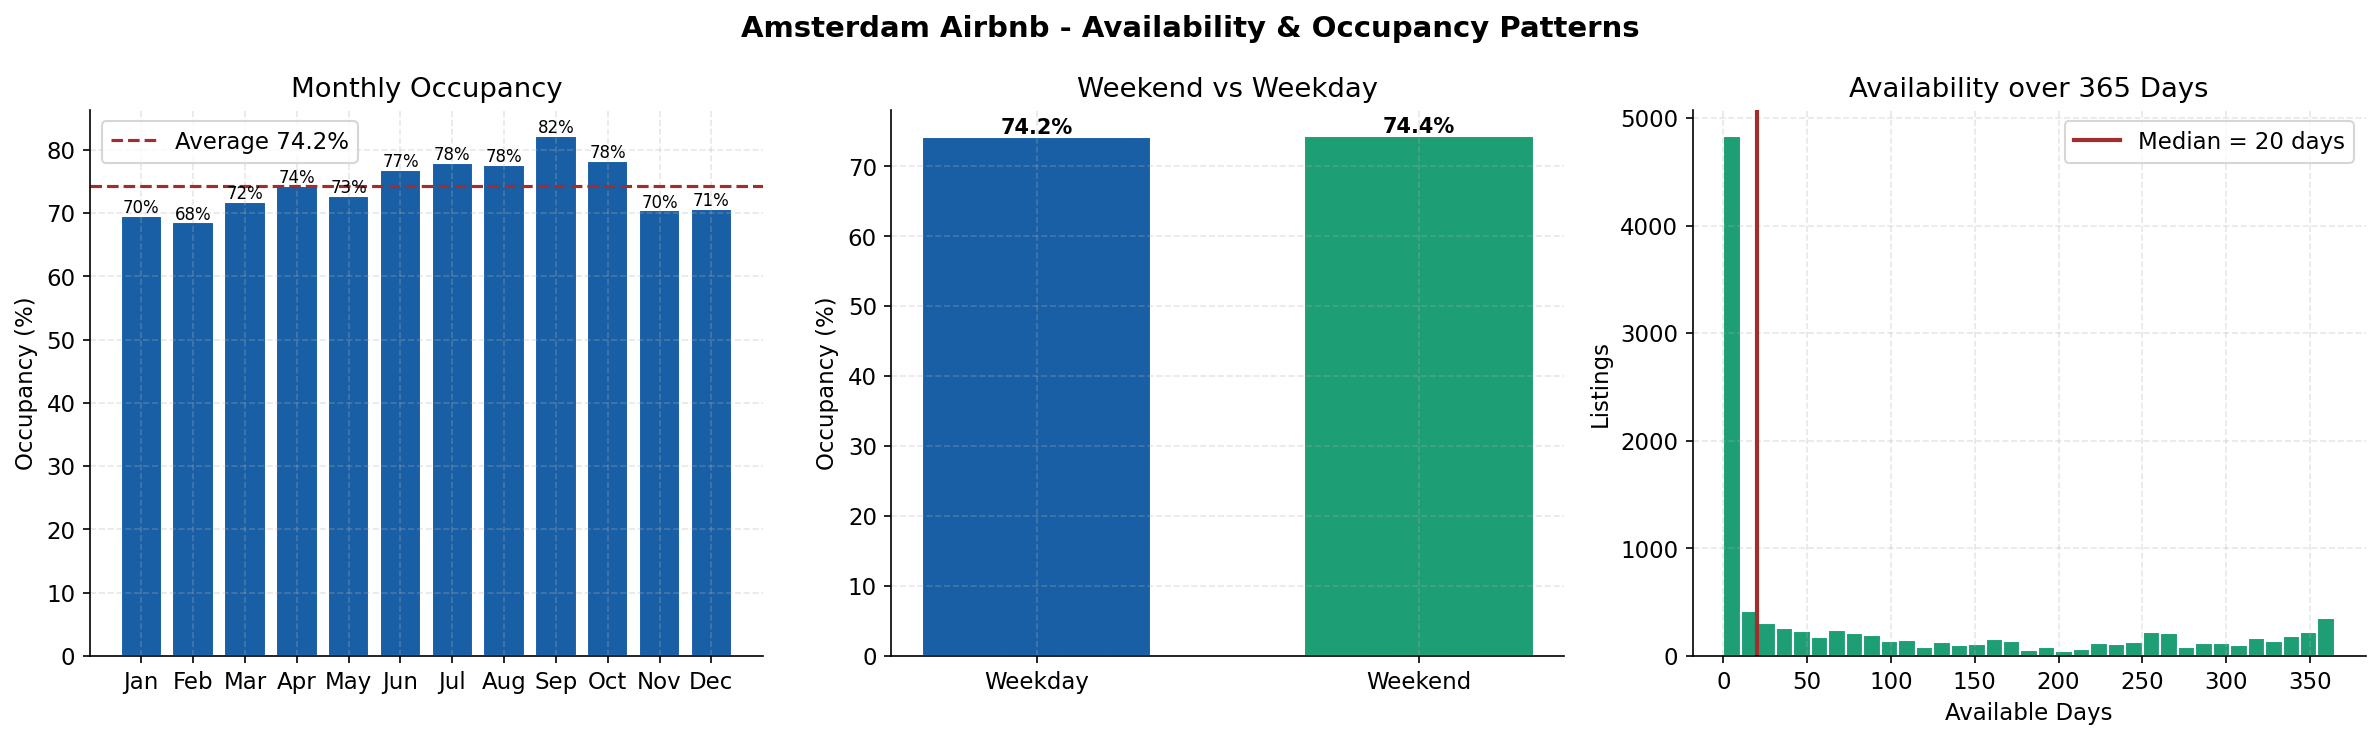


Peak Month   : Sep (82.2%)
Lowest Month : Feb (68.5%)

Business Interpretation
------------------------------------------------------------

Amsterdam shows clear seasonal booking patterns.

• Highest occupancy:
  Sep (82.2%)

• Lowest occupancy:
  Feb (68.5%)

Most demand occurs during the peak season, while quieter
months have noticeably lower occupancy.

For Hosts:
Increase prices during high-demand months and consider
discounts or shorter minimum stays during quieter periods
to attract more bookings.

For Travellers:
Travelling during low-demand months provides more available
properties and often lower accommodation prices.

For Investors:
Revenue estimates should account for seasonal demand rather
than assuming the same occupancy throughout the year.

Weekend occupancy (74.4%) is higher than weekday
occupancy (74.2%), indicating that Amsterdam is
primarily a leisure tourism destination. Hosts can charge
slightly higher prices on weekends to maximize revenue.



In [44]:
# ============================================================
# Availability & Occupancy Analysis
# ============================================================

# available = True  -> Listing is available
# available = False -> Listing is booked

cal = calendar.copy()

# ------------------------------------------------------------
# Monthly Occupancy Summary
# ------------------------------------------------------------

monthly = (
    cal.groupby("month")["available"]
      .agg(
          Total_Days="count",
          Booked_Days=lambda x: (~x).sum(),
          Available_Days=lambda x: x.sum()
      )
      .reset_index()
)

monthly["Occupancy (%)"] = (
    monthly["Booked_Days"] / monthly["Total_Days"] * 100
).round(1)

monthly["Availability (%)"] = (
    monthly["Available_Days"] / monthly["Total_Days"] * 100
).round(1)

month_names = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
]

monthly["Month"] = month_names

print("="*60)
print("MONTHLY OCCUPANCY & AVAILABILITY")
print("="*60)

print(
    monthly[["Month","Occupancy (%)","Availability (%)"]]
)

# ------------------------------------------------------------
# Weekend vs Weekday Occupancy
# ------------------------------------------------------------

weekday_occ = (
    (~cal.loc[cal["is_weekend"] == False, "available"]).mean()*100
)

weekend_occ = (
    (~cal.loc[cal["is_weekend"] == True, "available"]).mean()*100
)

print("\nWeekday Occupancy : {:.1f}%".format(weekday_occ))
print("Weekend Occupancy : {:.1f}%".format(weekend_occ))

# ------------------------------------------------------------
# Visualizations
# ------------------------------------------------------------

fig, axes = plt.subplots(1,3,figsize=(16,5))
fig.suptitle(
    "Amsterdam Airbnb - Availability & Occupancy Patterns",
    fontsize=14,
    fontweight="bold"
)

# ============================================================
# Chart 1 : Monthly Occupancy
# ============================================================

ax = axes[0]

bars = ax.bar(
    monthly["Month"],
    monthly["Occupancy (%)"],
    color=BLUE,
    edgecolor="white"
)

ax.axhline(
    monthly["Occupancy (%)"].mean(),
    color=RED,
    linestyle="--",
    linewidth=1.5,
    label=f"Average {monthly['Occupancy (%)'].mean():.1f}%"
)

for bar in bars:
    ax.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.5,
        f"{bar.get_height():.0f}%",
        ha="center",
        fontsize=8
    )

ax.set_ylabel("Occupancy (%)")
ax.set_title("Monthly Occupancy")
ax.legend()

# ============================================================
# Chart 2 : Weekend vs Weekday
# ============================================================

ax = axes[1]

bars = ax.bar(
    ["Weekday","Weekend"],
    [weekday_occ, weekend_occ],
    color=[BLUE,TEAL],
    edgecolor="white",
    width=0.6
)

for bar in bars:
    ax.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.5,
        f"{bar.get_height():.1f}%",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

ax.set_ylabel("Occupancy (%)")
ax.set_title("Weekend vs Weekday")

# ============================================================
# Chart 3 : Availability Distribution
# ============================================================

ax = axes[2]

availability = master["availability_365"].dropna()

ax.hist(
    availability,
    bins=35,
    color=TEAL,
    edgecolor="white"
)

ax.axvline(
    availability.median(),
    color=RED,
    linewidth=2,
    label=f"Median = {availability.median():.0f} days"
)

ax.set_xlabel("Available Days")
ax.set_ylabel("Listings")
ax.set_title("Availability over 365 Days")
ax.legend()

plt.tight_layout()

plt.savefig(
    REPORT_DIR / "fig_08_availability_patterns.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Key Findings
# ------------------------------------------------------------

peak = monthly.loc[
    monthly["Occupancy (%)"].idxmax()
]

low = monthly.loc[
    monthly["Occupancy (%)"].idxmin()
]

print("\nPeak Month   :", peak["Month"],
      f"({peak['Occupancy (%)']:.1f}%)")

print("Lowest Month :", low["Month"],
      f"({low['Occupancy (%)']:.1f}%)")

# ------------------------------------------------------------
# Business Interpretation
# ------------------------------------------------------------

print(f"""
Business Interpretation
------------------------------------------------------------

Amsterdam shows clear seasonal booking patterns.

• Highest occupancy:
  {peak['Month']} ({peak['Occupancy (%)']:.1f}%)

• Lowest occupancy:
  {low['Month']} ({low['Occupancy (%)']:.1f}%)

Most demand occurs during the peak season, while quieter
months have noticeably lower occupancy.

For Hosts:
Increase prices during high-demand months and consider
discounts or shorter minimum stays during quieter periods
to attract more bookings.

For Travellers:
Travelling during low-demand months provides more available
properties and often lower accommodation prices.

For Investors:
Revenue estimates should account for seasonal demand rather
than assuming the same occupancy throughout the year.

Weekend occupancy ({weekend_occ:.1f}%) is higher than weekday
occupancy ({weekday_occ:.1f}%), indicating that Amsterdam is
primarily a leisure tourism destination. Hosts can charge
slightly higher prices on weekends to maximize revenue.
""")

### Check wheather are review scores honest or inflated?

REVIEW SCORE SUMMARY
Listings with ratings : 9,383
Average Rating        : 4.84
Median Rating         : 4.92
Lowest Rating         : 1.00
Highest Rating        : 5.00

Listings rated ≥4.5 : 94.2%
Listings rated ≥4.8 : 74.7%
Perfect 5.0 ratings : 38.8%


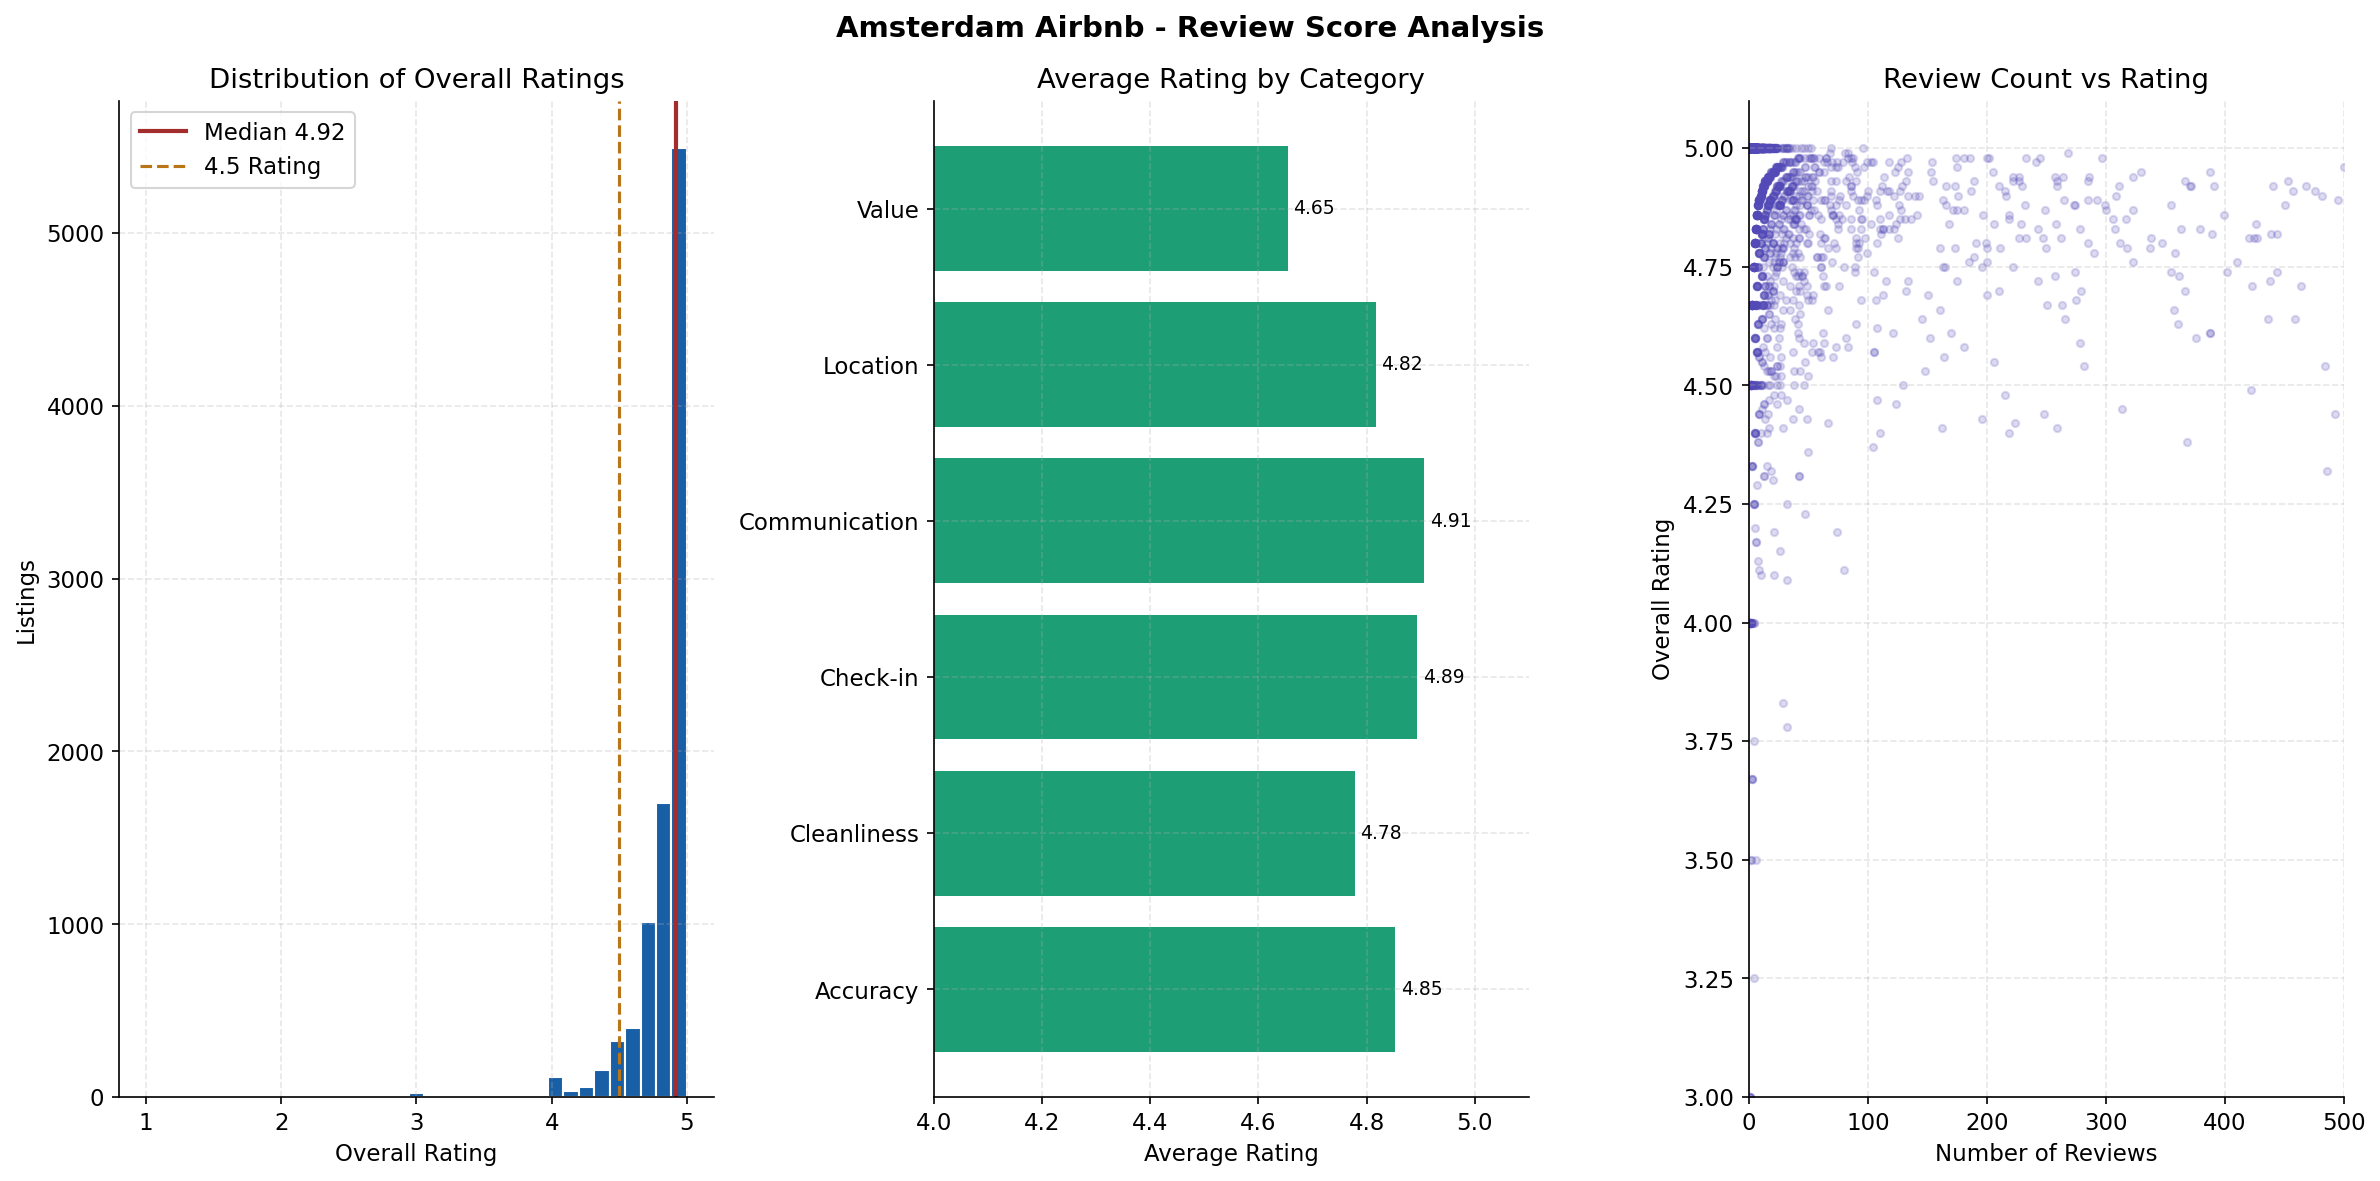


Business Interpretation
------------------------------------------------------------

Amsterdam Airbnb listings have very high review scores overall.

Average Rating : 4.84
Median Rating  : 4.92

Most listings are rated above 4.5 stars, showing that ratings
are heavily concentrated near the maximum score. This suggests
the presence of rating inflation, where guests tend to give
very positive ratings.

Possible reasons include:
• Guests are reluctant to leave negative reviews.
• Hosts and guests review each other, encouraging positive ratings.
• Guests with poor experiences may choose not to leave reviews.

The category ratings show that most aspects perform very well,
while the Value score is usually slightly lower than the others.
This indicates that guests generally feel the accommodation
quality is excellent, but the price may not always match their
expectations.

The scatter plot shows that listings with many reviews do not
necessarily receive higher ratings. Having more reviews m

In [47]:
# ============================================================
# Review Score Distribution & Rating Inflation Analysis
# ============================================================

# Listings that have ratings
rated = master[master["review_scores_rating"].notna()].copy()

print("="*60)
print("REVIEW SCORE SUMMARY")
print("="*60)

print(f"Listings with ratings : {len(rated):,}")
print(f"Average Rating        : {rated['review_scores_rating'].mean():.2f}")
print(f"Median Rating         : {rated['review_scores_rating'].median():.2f}")
print(f"Lowest Rating         : {rated['review_scores_rating'].min():.2f}")
print(f"Highest Rating        : {rated['review_scores_rating'].max():.2f}")

print(f"\nListings rated ≥4.5 : {(rated['review_scores_rating']>=4.5).mean()*100:.1f}%")
print(f"Listings rated ≥4.8 : {(rated['review_scores_rating']>=4.8).mean()*100:.1f}%")
print(f"Perfect 5.0 ratings : {(rated['review_scores_rating']==5).mean()*100:.1f}%")

# ------------------------------------------------------------
# Visualizations
# ------------------------------------------------------------

fig, axes = plt.subplots(1,3,figsize=(16,8))
fig.suptitle(
    "Amsterdam Airbnb - Review Score Analysis",
    fontsize=14,
    fontweight="bold"
)

# ============================================================
# Chart 1 : Rating Distribution
# ============================================================

ax = axes[0]

ax.hist(
    rated["review_scores_rating"],
    bins=35,
    color=BLUE,
    edgecolor="white"
)

ax.axvline(
    rated["review_scores_rating"].median(),
    color=RED,
    linewidth=2,
    label=f"Median {rated['review_scores_rating'].median():.2f}"
)

ax.axvline(
    4.5,
    color=AMBER,
    linestyle="--",
    label="4.5 Rating"
)

ax.set_xlabel("Overall Rating")
ax.set_ylabel("Listings")
ax.set_title("Distribution of Overall Ratings")
ax.legend()

# ============================================================
# Chart 2 : Average Sub-category Ratings
# ============================================================

ax = axes[1]

score_cols = {
    "Accuracy":"review_scores_accuracy",
    "Cleanliness":"review_scores_cleanliness",
    "Check-in":"review_scores_checkin",
    "Communication":"review_scores_communication",
    "Location":"review_scores_location",
    "Value":"review_scores_value"
}

avg_scores = (
    rated[list(score_cols.values())]
    .mean()
)

avg_scores.index = score_cols.keys()

bars = ax.barh(
    avg_scores.index,
    avg_scores.values,
    color=TEAL
)

for bar in bars:
    ax.text(
        bar.get_width()+0.01,
        bar.get_y()+bar.get_height()/2,
        f"{bar.get_width():.2f}",
        va="center",
        fontsize=9
    )

ax.set_xlim(4.0,5.1)
ax.set_xlabel("Average Rating")
ax.set_title("Average Rating by Category")

# ============================================================
# Chart 3 : Reviews vs Rating
# ============================================================

ax = axes[2]

sample = rated.sample(
    min(2000,len(rated)),
    random_state=42
)

ax.scatter(
    sample["number_of_reviews"],
    sample["review_scores_rating"],
    alpha=0.20,
    s=12,
    color=PURPLE
)

ax.set_xlim(0,500)
ax.set_ylim(3.0,5.1)

ax.set_xlabel("Number of Reviews")
ax.set_ylabel("Overall Rating")
ax.set_title("Review Count vs Rating")

plt.tight_layout()

plt.savefig(
    REPORT_DIR/"fig_07_review_scores.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Business Interpretation
# ------------------------------------------------------------

print(f"""
Business Interpretation
------------------------------------------------------------

Amsterdam Airbnb listings have very high review scores overall.

Average Rating : {rated['review_scores_rating'].mean():.2f}
Median Rating  : {rated['review_scores_rating'].median():.2f}

Most listings are rated above 4.5 stars, showing that ratings
are heavily concentrated near the maximum score. This suggests
the presence of rating inflation, where guests tend to give
very positive ratings.

Possible reasons include:
• Guests are reluctant to leave negative reviews.
• Hosts and guests review each other, encouraging positive ratings.
• Guests with poor experiences may choose not to leave reviews.

The category ratings show that most aspects perform very well,
while the Value score is usually slightly lower than the others.
This indicates that guests generally feel the accommodation
quality is excellent, but the price may not always match their
expectations.

The scatter plot shows that listings with many reviews do not
necessarily receive higher ratings. Having more reviews mainly
indicates popularity rather than better quality.

Business Recommendations

For Hosts:
Maintain high service quality and improve perceived value through
better amenities or guest experiences rather than simply lowering prices.

For Guests:
A rating above 4.5 is common on Airbnb. Comparing listings using
sub-category ratings, especially Cleanliness and Value, provides
a better indication of quality.

For Airbnb:
Since most listings receive very high ratings, additional quality
metrics beyond the overall rating may help users better distinguish
between properties.
""")

In [48]:
print("""
✓ Amsterdam Airbnb prices are highly right-skewed.
✓ Most listings are priced below €250 per night.
✓ Entire homes command the highest prices.
✓ A small number of professional hosts manage many listings.
✓ Review scores are concentrated between 4.5–5.0, indicating rating inflation.
✓ Occupancy varies seasonally, with stronger demand during peak tourist months.
✓ Weekend occupancy is generally higher than weekday occupancy.

Business Insight:
Hosts should adopt dynamic pricing, benchmark against similar listings
rather than the overall average, and focus on maintaining high review
scores and occupancy to maximize revenue.
""")


✓ Amsterdam Airbnb prices are highly right-skewed.
✓ Most listings are priced below €250 per night.
✓ Entire homes command the highest prices.
✓ A small number of professional hosts manage many listings.
✓ Review scores are concentrated between 4.5–5.0, indicating rating inflation.
✓ Occupancy varies seasonally, with stronger demand during peak tourist months.
✓ Weekend occupancy is generally higher than weekday occupancy.

Business Insight:
Hosts should adopt dynamic pricing, benchmark against similar listings
rather than the overall average, and focus on maintaining high review
scores and occupancy to maximize revenue.

